In [ ]:
# === Step 4: 以「多重或無匹配」邏輯找最佳 threshold ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

thresholds = np.arange(0.2, 0.8, 0.01)
results = []

for th in thresholds:
    success = 0
    fail = 0

    # 每張測試照為單位
    for test_name in df["測試照片"].unique():
        subset = df[df["測試照片"] == test_name]
        match_count = np.sum(subset["相似度"] >= th)

        if match_count == 1:
            success += 1  # 剛好 1 個成功
        else:
            fail += 1     # 0 個或 >1 都算失敗

    acc = success / (success + fail)
    results.append({
        "threshold": th,
        "success": success,
        "fail": fail,
        "accuracy": acc
    })

# 統整結果
result_df = pd.DataFrame(results)
best_row = result_df.loc[result_df["accuracy"].idxmax()]

print("\n=== 最佳相似度門檻 (多重／無匹配邏輯) ===")
print(f"✅ 最佳 threshold: {best_row['threshold']:.2f}")
print(f"   成功: {best_row['success']} | 失敗: {best_row['fail']}")
print(f"   成功率: {best_row['accuracy']*100:.2f}%")

# 可視化趨勢
plt.figure(figsize=(8,5))
plt.plot(result_df["threshold"], result_df["accuracy"], marker="o")
plt.title("不同相似度門檻下的成功率")
plt.xlabel("相似度門檻 threshold")
plt.ylabel("成功率 (剛好一個匹配)")
plt.grid(True)
plt.show()
clean_df = result_df[["threshold", "accuracy"]]
print(clean_df.to_string(index=False))
clean_df.to_csv("threshold_accuracy_clean.csv", index=False)


# 11/15 修改通緝犯照片demo格式

#版本一

In [ ]:
!pip install catboost gradio insightface onnxruntime --quiet
import gradio as gr
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from insightface.app import FaceAnalysis
from PIL import Image
import cv2
from google.colab import files
import os

# ==========================
# 1️⃣ 上傳訓練資料 (output.csv)
# ==========================
print("📤 請上傳 output.csv 檔案")
uploaded = files.upload()
train_file = list(uploaded.keys())[0]
df_train = pd.read_csv(train_file)
feature_cols = [c for c in df_train.columns if c not in ['測試照片','Baseline照片','結果','label']]
X_train = df_train[feature_cols]
y_train = df_train['label']

# 訓練 CatBoost 模型
model = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1,
                           loss_function='Logloss', eval_metric='AUC', verbose=False)
model.fit(Pool(X_train, y_train))
print("✅ CatBoost 訓練完成")

# ==========================
# 2️⃣ 上傳通緝犯照片
# ==========================
print("📤 請依序上傳 5 張通緝犯照片 (或按 Skip)")
wanted_criminals = []
for i in range(5):
    print(f"上傳第 {i+1} 位通緝犯照片（或 Skip）")
    uploaded_criminal = files.upload()
    if uploaded_criminal:
        criminal_file = list(uploaded_criminal.keys())[0]
        wanted_criminals.append(criminal_file)
    else:
        wanted_criminals.append(None)
        print(f"第 {i+1} 位已跳過")

# 保存通緝犯照片路徑
criminal_paths = []
for i, crim_file in enumerate(wanted_criminals):
    if crim_file:
        criminal_paths.append(crim_file)
    else:
        criminal_paths.append(None)

print(f"✅ 已載入 {len([p for p in criminal_paths if p])} 位通緝犯")

# ==========================
# 3️⃣ InsightFace 初始化
# ==========================
app = FaceAnalysis()
app.prepare(ctx_id=0)

def compute_similarity(img1_path, img2_path):
    try:
        img1 = cv2.imread(img1_path)
        img2 = cv2.imread(img2_path)
        if img1 is None or img2 is None:
            return 0.0
        faces1 = app.get(img1)
        faces2 = app.get(img2)
        if len(faces1)==0 or len(faces2)==0:
            return 0.0
        feat1 = faces1[0].embedding
        feat2 = faces2[0].embedding
        cos_sim = np.dot(feat1, feat2)/(np.linalg.norm(feat1)*np.linalg.norm(feat2))
        return float(cos_sim)
    except:
        return 0.0

# ==========================
# 4️⃣ Gradio 預測函式
# ==========================
def predict_demo(baseline_img, test_img, glasses, mask, hat, helmet):
    if test_img is None:
        return "❌ 請上傳測試照片", "尚未比對"

    baseline_img_path = "baseline.jpg"
    test_img_path = "test.jpg"
    test_img.save(test_img_path)

    # 計算與所有通緝犯的相似度
    similarities = []
    for i, crim_path in enumerate(criminal_paths):
        if crim_path and os.path.exists(crim_path):
            sim = compute_similarity(crim_path, test_img_path)
            similarities.append((i+1, sim))
        else:
            similarities.append((i+1, 0.0))

    # 加上 baseline 照片的相似度
    if baseline_img is not None:
        baseline_img.save(baseline_img_path)
        sim_baseline = compute_similarity(baseline_img_path, test_img_path)
        similarities.append((6, sim_baseline))
    else:
        similarities.append((6, 0.0))

    # 找最高相似度
    max_sim_idx = np.argmax([s[1] for s in similarities])
    max_sim_value = similarities[max_sim_idx][1]
    max_criminal_id = similarities[max_sim_idx][0]

    # 手動特徵
    manual_features = {
        'glasses': int(glasses),
        'mask': int(mask),
        'hat': int(hat),
        'Lhelmet': int(helmet)
    }

    # 組合特徵
    combined = {c: 0 for c in feature_cols}
    combined.update(manual_features)
    combined['相似度'] = max_sim_value

    X_test = pd.DataFrame([combined], columns=feature_cols)
    proba = model.predict_proba(X_test)[:,1][0]
    label = "✅ Same person" if proba > 0.5 else "❌ Not same person"

    # 相似度表格
    similarity_text = "📊 所有通緝犯相似度比對：\n" + "="*50 + "\n"
    for idx, (crim_id, sim) in enumerate(similarities):
        bar_len = int(sim * 20)
        bar = "█" * bar_len + "░" * (20 - bar_len)
        crim_label = "【通緝犯 #6】" if crim_id == 6 else f"【通緝犯 #{crim_id}】"
        marker = " ⭐ 最高匹配" if crim_id == max_criminal_id else ""
        similarity_text += f"{crim_label} {sim:.3f} [{bar}]{marker}\n"

    prediction_result = f"🎯 最高相似對象：{'通緝犯 #6' if max_criminal_id == 6 else f'通緝犯 #{max_criminal_id}'}\n相似度：{max_sim_value:.3f}\n\n{label}\nCatBoost 機率：{proba:.3f}"

    return prediction_result, similarity_text

# ==========================
# 5️⃣ 製作統一大小照片
# ==========================
def get_display_image(img_path):
    """載入並調整照片大小到統一尺寸"""
    try:
        if img_path and os.path.exists(img_path):
            img = Image.open(img_path)
            # 調整到 280x280，保持比例縮放
            img.thumbnail((280, 280), Image.Resampling.LANCZOS)
            # 創建背景並置中
            new_img = Image.new('RGB', (280, 280), color=(240, 240, 245))
            offset = ((280 - img.size[0]) // 2, (280 - img.size[1]) // 2)
            new_img.paste(img, offset)
            return new_img
        return None
    except:
        return None

# ==========================
# 6️⃣ Gradio 介面（完整重做）
# ==========================
with gr.Blocks(theme=gr.themes.Soft(), css="""
    .criminal-grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 12px; }
    .criminal-card { border-radius: 12px; overflow: hidden; box-shadow: 0 2px 8px rgba(0,0,0,0.1); }
    .criminal-card img { width: 100%; height: 280px; object-fit: cover; }
    .criminal-label { padding: 8px; text-align: center; font-size: 14px; font-weight: 600; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; }
    .section-title { font-size: 18px; font-weight: bold; margin-bottom: 12px; color: #333; }
    .input-section { background: #f8f9fa; border-radius: 12px; padding: 20px; }
    .output-section { background: #ffffff; border-radius: 12px; padding: 16px; border: 1px solid #e0e0e0; }
""") as demo:

    gr.Markdown("# 🎭 Face Recognition System")
    gr.Markdown("通緝犯人臉辨識系統 - InsightFace + CatBoost")

    with gr.Row():
        # 左側：通緝犯檔案展示
        with gr.Column(scale=1.2):
            gr.Markdown("### 📋 通緝犯檔案 (6位)")

            # 通緝犯照片網格 (3x2)
            criminal_displays = []
            with gr.Group():
                for row in range(2):
                    with gr.Row():
                        for col in range(3):
                            idx = row * 3 + col
                            with gr.Column():
                                if idx < 5:
                                    if criminal_paths[idx] and os.path.exists(criminal_paths[idx]):
                                        img = get_display_image(criminal_paths[idx])
                                        if img:
                                            gr.Image(value=img, label=f"通緝犯 #{idx+1}", type="pil", interactive=False, show_label=True)
                                        else:
                                            gr.Textbox(value=f"❌ 通緝犯 #{idx+1}\n載入失敗", interactive=False, label="")
                                    else:
                                        gr.Image(value=Image.new('RGB', (280, 280), color=(220, 220, 220)),
                                                label=f"未上傳", interactive=False, show_label=False)
                                else:
                                    # 第6格：上傳欄
                                    baseline_img = gr.Image(type="pil", label="📤 通緝犯 #6", interactive=True, height=280)

            # 相似度結果
            gr.Markdown("### 📊 相似度分析")
            similarity_output = gr.Textbox(label="", lines=10, interactive=False,
                                          elem_classes="output-section")

        # 右側：操作面板
        with gr.Column(scale=0.8):
            gr.Markdown("### 🔍 測試照片")
            test_img = gr.Image(type="pil", label="上傳測試照片", interactive=True)

            gr.Markdown("### 👤 配件特徵")
            with gr.Group(elem_classes="input-section"):
                glasses = gr.Checkbox(label="🥽 戴眼鏡", scale=1)
                mask = gr.Checkbox(label="😷 戴口罩", scale=1)
                hat = gr.Checkbox(label="🧢 戴帽子", scale=1)
                helmet = gr.Checkbox(label="🪖 戴安全帽", scale=1)

            gr.Markdown("### 🎯 預測結果")
            prediction_output = gr.Textbox(label="", lines=8, interactive=False,
                                          elem_classes="output-section")

            predict_btn = gr.Button("🚀 開始比對", size="lg", variant="primary")

    # 按鈕動作
    predict_btn.click(
        fn=predict_demo,
        inputs=[baseline_img, test_img, glasses, mask, hat, helmet],
        outputs=[prediction_output, similarity_output]
    )

demo.launch()

# 11/8

# Demo 雛形 非Gemini 改成手動勾選生成特徵欄位版本 (方便來展的人互動
需匯入 output.csv 👇

已整合前面的InsightFace相似度特徵 和catboost 訓練

In [ ]:
!pip install catboost gradio insightface onnxruntime --quiet

import gradio as gr
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from insightface.app import FaceAnalysis
from PIL import Image
import cv2
from google.colab import files

# ==========================
# 1️⃣ 上傳訓練資料 (output.csv)
# ==========================
print("📤 請上傳 output.csv 檔案")
uploaded = files.upload()
train_file = list(uploaded.keys())[0]
df_train = pd.read_csv(train_file)

feature_cols = [c for c in df_train.columns if c not in ['測試照片','Baseline照片','結果','label']]

X_train = df_train[feature_cols]
y_train = df_train['label']

# 訓練 CatBoost 模型
model = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1,
                           loss_function='Logloss', eval_metric='AUC', verbose=False)
model.fit(Pool(X_train, y_train))
print("✅ CatBoost 訓練完成")

# ==========================
# 2️⃣ InsightFace 初始化
# ==========================
app = FaceAnalysis()
app.prepare(ctx_id=0)

def compute_similarity(img1_path, img2_path):
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    faces1 = app.get(img1)
    faces2 = app.get(img2)
    if len(faces1)==0 or len(faces2)==0:
        return 0.0
    feat1 = faces1[0].embedding
    feat2 = faces2[0].embedding
    cos_sim = np.dot(feat1, feat2)/(np.linalg.norm(feat1)*np.linalg.norm(feat2))
    return float(cos_sim)

# ==========================
# 3️⃣ Gradio 預測函式（手動勾選）
# ==========================
def predict_demo(baseline_img, test_img, glasses, mask, hat, helmet):
    baseline_img_path = "baseline.jpg"
    test_img_path = "test.jpg"
    baseline_img.save(baseline_img_path)
    test_img.save(test_img_path)

    # InsightFace 相似度
    sim = compute_similarity(baseline_img_path, test_img_path)

    # 手動特徵（勾選轉為 0/1）
    manual_features = {
        'glasses': int(glasses),
        'mask': int(mask),
        'hat': int(hat),
        'Lhelmet': int(helmet)
    }

    # 其他欄位補0（確保欄位對齊）
    combined = {c: 0 for c in feature_cols}
    combined.update(manual_features)
    combined['相似度'] = sim

    X_test = pd.DataFrame([combined], columns=feature_cols)

    proba = model.predict_proba(X_test)[:,1][0]
    label = "✅ Same person" if proba > 0.5 else "❌ Not same person"

    return f"{label}\n相似度：{sim:.3f}\nCatBoost 機率：{proba:.3f}"

# ==========================
# 4️⃣ Gradio 介面
# ==========================
iface = gr.Interface(
    fn=predict_demo,
    inputs=[
        gr.Image(type="pil", label="Baseline 照片", elem_id="baseline_img"),
        gr.Image(type="pil", label="Test 照片", elem_id="test_img"),
        gr.Checkbox(label="戴眼鏡 👓"),
        gr.Checkbox(label="戴口罩 😷"),
        gr.Checkbox(label="戴帽子 🧢"),
        gr.Checkbox(label="戴安全帽 🪖")
    ],
    outputs=gr.Textbox(label="預測結果", lines=5),
    title="🎭 Face Recognition Demo ",
    description="上傳兩張臉部照片，勾選配件後，顯示相似度與模型預測結果",
    css="""
        #baseline_img img, #test_img img {
            max-width: 300px;
            max-height: 300px;
        }
        .output-textbox {width: 800px !important;}
    """

)

iface.launch()


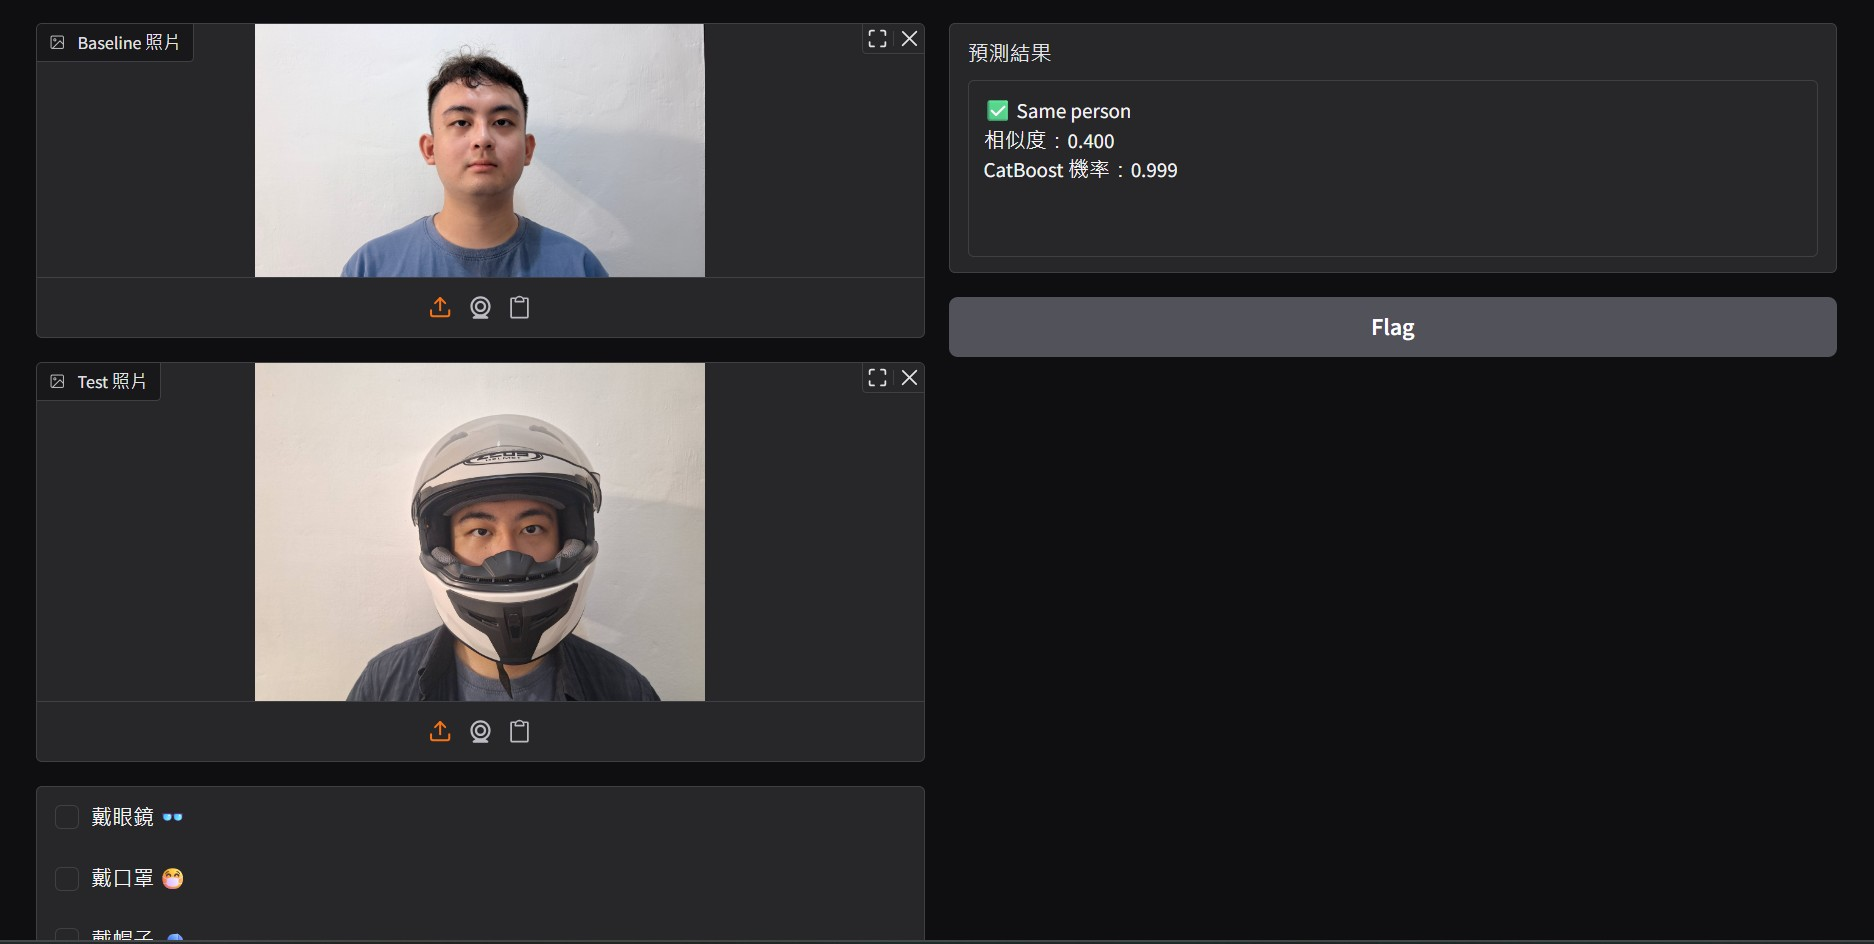

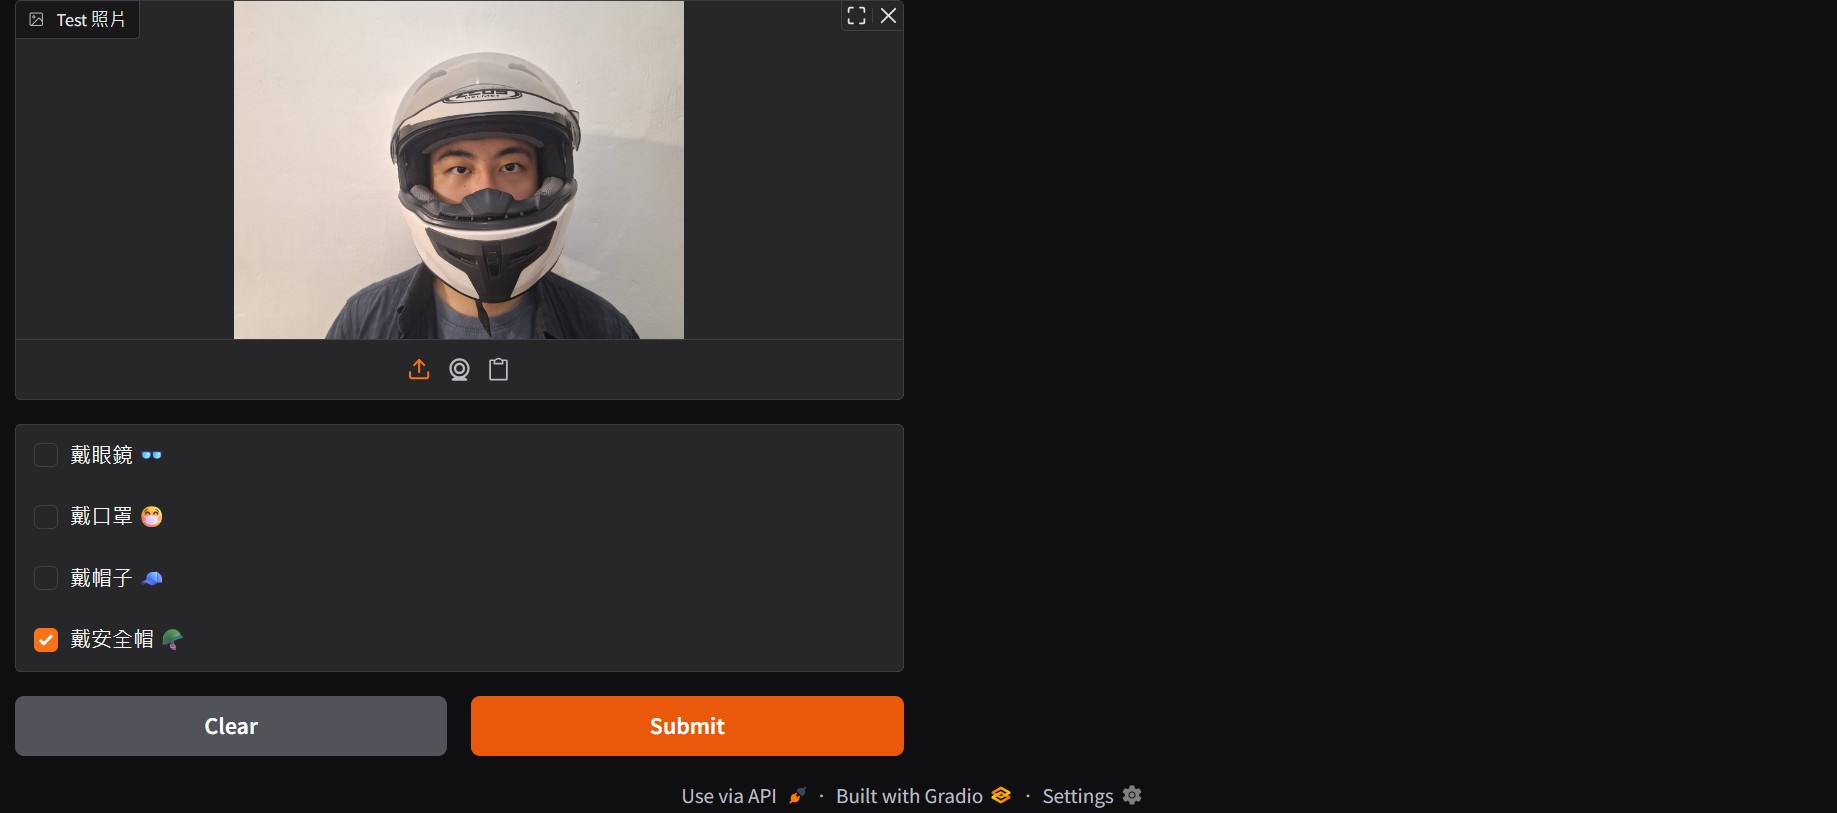

# 這個DEmo目前沒加Gemini 的feature csv....

In [ ]:
!pip install catboost gradio --quiet
!pip install insightface --quiet  # 如果還沒裝
!pip install onnxruntime --quiet


import gradio as gr
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
import insightface
from PIL import Image

# ==========================
# 1️⃣ 上傳訓練資料 (output.csv)
# ==========================
from google.colab import files
uploaded = files.upload()
train_file = list(uploaded.keys())[0]
df_train = pd.read_csv(train_file)

feature_cols = [c for c in df_train.columns if c not in ['測試照片','Baseline照片','結果','label']]

X_train = df_train[feature_cols]
y_train = df_train['label']

# 訓練 CatBoost 模型
model = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1,
                           loss_function='Logloss', eval_metric='AUC', verbose=False)
model.fit(Pool(X_train, y_train))

print("✅ CatBoost 訓練完成")

# ==========================
# 2️⃣ InsightFace 模型
# ==========================
# 使用 ArcFace 預訓練模型
import cv2
import numpy as np
from insightface.app import FaceAnalysis

app = FaceAnalysis()
app.prepare(ctx_id=0)

def compute_similarity(img1_path, img2_path):
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    faces1 = app.get(img1)
    faces2 = app.get(img2)
    if len(faces1)==0 or len(faces2)==0:
        return 0.0
    feat1 = faces1[0].embedding
    feat2 = faces2[0].embedding
    cos_sim = np.dot(feat1, feat2)/(np.linalg.norm(feat1)*np.linalg.norm(feat2))
    return float(cos_sim)

# ==========================
# 3️⃣ 假設 Gemini API 函式 (回傳 dict 特徵 0/1)
# ==========================
def call_gemini_api(img_path):
    """
    這裡示意，實務上要改成呼叫 Gemini API
    回傳字典：key = 特徵欄位名, value = 0/1
    """
    # TODO: 用實際 Gemini API 替換
    features = {
        'Bgray':0, 'Bwhite':0, 'Bnight':0, 'Lhelmet':0, 'Mhelmet':0,
        'Shelmet':0, 'cap':0, 'glasses':0, 'hat':0, 'mask':0,
        'non':0, 'sunglasses1':0, 'sunglasses2':0
    }
    # 假設圖片名稱含關鍵字
    name = img_path.lower()
    if 'gray' in name: features['Bgray']=1
    if 'white' in name: features['Bwhite']=1
    if 'night' in name: features['Bnight']=1
    if 'helmet' in name: features['Lhelmet']=1
    if 'cap' in name: features['cap']=1
    if 'glasses' in name: features['glasses']=1
    if 'mask' in name: features['mask']=1
    return features

# ==========================
# 4️⃣ Gradio 預測函式
# ==========================
def predict_demo(baseline_img, test_img):
    # 保存上傳圖片
    baseline_img_path = "baseline.jpg"
    test_img_path = "test.jpg"
    baseline_img.save(baseline_img_path)
    test_img.save(test_img_path)

    # InsightFace 相似度
    sim = compute_similarity(baseline_img_path, test_img_path)

    # Gemini 特徵
    baseline_feat = call_gemini_api(baseline_img_path)
    test_feat = call_gemini_api(test_img_path)

    # 合併特徵
    combined = {}
    combined.update(baseline_feat)
    combined.update(test_feat)
    combined['相似度'] = sim

    # 對應訓練的欄位順序
    X_test = pd.DataFrame([combined], columns=feature_cols)

    # CatBoost 預測機率
    proba = model.predict_proba(X_test)[:,1][0]
    label = "✅ Same person" if proba>0.5 else "❌ Not same person"

    return f"{label}\n相似度：{sim:.3f}\nCatBoost 機率：{proba:.3f}"

# ==========================
# 5️⃣ Gradio 介面
# ==========================
iface = gr.Interface(
    fn=predict_demo,
    inputs=[gr.Image(type="pil"), gr.Image(type="pil")],
    outputs="text",
    title="Demo: Face Recognition + CatBoost",
    description="上傳 Baseline 與 Test Photo，顯示是否為同一人、相似度與 CatBoost 機率"
)
iface.launch()


伍:上傳照片自動產生output.csv  (不太可行 要重新自己蒐集照片訓練偵測特定物件的模型；另解是簡單使用Teachable Machine 做訓練)

#javascript和p5.js
<div>Teachable Machine Image Model</div>
<button type="button" onclick="init()">Start</button>
<div id="webcam-container"></div>
<div id="label-container"></div>
<script src="https://cdn.jsdelivr.net/npm/@tensorflow/tfjs@latest/dist/tf.min.js"></script>
<script src="https://cdn.jsdelivr.net/npm/@teachablemachine/image@latest/dist/teachablemachine-image.min.js"></script>
<script type="text/javascript">
    // More API functions here:
    // https://github.com/googlecreativelab/teachablemachine-community/tree/master/libraries/image

    // the link to your model provided by Teachable Machine export panel
    const URL = "./my_model/";

    let model, webcam, labelContainer, maxPredictions;

    // Load the image model and setup the webcam
    async function init() {
        const modelURL = URL + "model.json";
        const metadataURL = URL + "metadata.json";

        // load the model and metadata
        // Refer to tmImage.loadFromFiles() in the API to support files from a file picker
        // or files from your local hard drive
        // Note: the pose library adds "tmImage" object to your window (window.tmImage)
        model = await tmImage.load(modelURL, metadataURL);
        maxPredictions = model.getTotalClasses();

        // Convenience function to setup a webcam
        const flip = true; // whether to flip the webcam
        webcam = new tmImage.Webcam(200, 200, flip); // width, height, flip
        await webcam.setup(); // request access to the webcam
        await webcam.play();
        window.requestAnimationFrame(loop);

        // append elements to the DOM
        document.getElementById("webcam-container").appendChild(webcam.canvas);
        labelContainer = document.getElementById("label-container");
        for (let i = 0; i < maxPredictions; i++) { // and class labels
            labelContainer.appendChild(document.createElement("div"));
        }
    }

    async function loop() {
        webcam.update(); // update the webcam frame
        await predict();
        window.requestAnimationFrame(loop);
    }

    // run the webcam image through the image model
    async function predict() {
        // predict can take in an image, video or canvas html element
        const prediction = await model.predict(webcam.canvas);
        for (let i = 0; i < maxPredictions; i++) {
            const classPrediction =
                prediction[i].className + ": " + prediction[i].probability.toFixed(2);
            labelContainer.childNodes[i].innerHTML = classPrediction;
        }
    }
</script>


<div>Teachable Machine Image Model - p5.js and ml5.js</div>
<script src="https://cdn.jsdelivr.net/npm/p5@latest/lib/p5.min.js"></script>
<script src="https://cdn.jsdelivr.net/npm/p5@latest/lib/addons/p5.dom.min.js"></script>
<script src="https://cdn.jsdelivr.net/npm/ml5@latest/dist/ml5.min.js"></script>
<script type="text/javascript">
  // Classifier Variable
  let classifier;
  // Model URL
  let imageModelURL = './my_model/';
  
  // Video
  let video;
  let flippedVideo;
  // To store the classification
  let label = "";

  // Load the model first
  function preload() {
    classifier = ml5.imageClassifier(imageModelURL + 'model.json');
  }

  function setup() {
    createCanvas(320, 260);
    // Create the video
    video = createCapture(VIDEO);
    video.size(320, 240);
    video.hide();

    flippedVideo = ml5.flipImage(video);
    // Start classifying
    classifyVideo();
  }

  function draw() {
    background(0);
    // Draw the video
    image(flippedVideo, 0, 0);

    // Draw the label
    fill(255);
    textSize(16);
    textAlign(CENTER);
    text(label, width / 2, height - 4);
  }

  // Get a prediction for the current video frame
  function classifyVideo() {
    flippedVideo = ml5.flipImage(video)
    classifier.classify(flippedVideo, gotResult);
    flippedVideo.remove();

  }

  // When we get a result
  function gotResult(error, results) {
    // If there is an error
    if (error) {
      console.error(error);
      return;
    }
    // The results are in an array ordered by confidence.
    // console.log(results[0]);
    label = results[0].label;
    // Classifiy again!
    classifyVideo();
  }
</script>



每一個threshold 的每個組合 performance 的平均,例如要看大家在threshold= 0.2表現怎麼樣(範圍為0.2~0.55)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# 1️⃣ 上傳 CSV
print("請上傳 LOO_threshold_scan_results.csv")
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]
df = pd.read_csv(csv_file)
print(f"✅ 成功讀取 {csv_file}")

# 2️⃣ 計算每個 threshold 的平均 performance
threshold_summary = df.groupby('Threshold')[['Precision','Recall','F1','Accuracy']].mean().reset_index()
print("\n📊 Threshold 平均 Performance:")
print(threshold_summary)

# 3️⃣ 畫折線圖
plt.figure(figsize=(10,6))
plt.plot(threshold_summary['Threshold'], threshold_summary['F1'], marker='o', label='F1 Score')
plt.plot(threshold_summary['Threshold'], threshold_summary['Accuracy'], marker='s', label='Accuracy')
plt.xlabel('Threshold')
plt.ylabel('Performance')
plt.title('Threshold vs F1 / Accuracy')
plt.grid(True)
plt.legend()
plt.xticks(threshold_summary['Threshold'])
plt.show()

# 4️⃣ 選最佳 threshold
best_idx = threshold_summary['F1'].idxmax()
best_threshold = threshold_summary.loc[best_idx, 'Threshold']
best_f1 = threshold_summary.loc[best_idx, 'F1']
print(f"\n🏆 建議最佳 threshold = {best_threshold:.2f} (F1={best_f1:.3f})")


# 10/25

伍嘗試

In [ ]:
!pip install catboost --quiet

import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import KFold
import numpy as np
import itertools
from google.colab import files
import os

# ==========================
# 0️⃣ 參數設定
# ==========================
use_test_person = True
test_person_name = "第六人"
main_data_file = "output 1.csv"

k_inner = 3  # 內層交叉驗證 k 值
thresholds = np.arange(0.2, 0.55, 0.01)

# ==========================
# 1️⃣ 上傳主要資料 (前五人)
# ==========================
print(f"請上傳主要 feature 資料：{main_data_file}")
try:
    if not os.path.exists(main_data_file):
        uploaded = files.upload()
        if main_data_file not in uploaded:
            main_data_file = list(uploaded.keys())[0]
            print(f"使用已上傳的檔案: {main_data_file}")
    df = pd.read_csv(main_data_file)
    print(f"✅ 成功載入 {main_data_file} ({len(df)} 筆資料)")
except Exception as e:
    print(f"❌ 載入主要資料時發生錯誤: {e}")
    exit()

# ==========================
# 2️⃣ 設定人名與特徵欄位
# ==========================
people = ['鈺威', '瑋志', '黨勝', '子泰', '我']
feature_cols = [c for c in df.columns if c not in ['測試照片','Baseline照片','結果','label']]

outer_results = []
summary_records = []

# ==========================
# 3️⃣ Nested Cross Validation
# ==========================
print("\n--- 開始 Nested Cross-Validation (外層 LOO, 內層 k-fold) ---")

for test_person in people:
    print(f"\n🚀 外層：{test_person} 當 Test Person")

    # === 外層分割 ===
    outer_test_mask = df['測試照片'].str.contains(f"\\({test_person}\\)", regex=True)
    outer_train = df.loc[~outer_test_mask]
    X_outer_train = outer_train[feature_cols].values
    y_outer_train = outer_train['label'].values

    # === 內層 k-fold ===
    kf = KFold(n_splits=k_inner, shuffle=True, random_state=42)
    f1_scores_by_t = {t: [] for t in thresholds}

    for inner_fold, (train_idx, val_idx) in enumerate(kf.split(X_outer_train)):
        X_train, X_val = X_outer_train[train_idx], X_outer_train[val_idx]
        y_train, y_val = y_outer_train[train_idx], y_outer_train[val_idx]

        model = CatBoostClassifier(
            iterations=200, depth=6, learning_rate=0.1,
            loss_function='Logloss', eval_metric='AUC',
            random_seed=42, verbose=False
        )
        model.fit(Pool(X_train, y_train))
        y_pred_proba = model.predict_proba(X_val)[:, 1]

        # 掃 threshold 計算每 fold 的 F1
        for t in thresholds:
            y_pred = (y_pred_proba > t).astype(int)
            f1 = f1_score(y_val, y_pred, zero_division=0)
            f1_scores_by_t[t].append(f1)

    # === 根據內層平均 F1 選最佳 threshold ===
    avg_f1_by_t = {t: np.mean(f1_scores_by_t[t]) for t in thresholds}
    best_t = max(avg_f1_by_t, key=avg_f1_by_t.get)
    best_f1 = avg_f1_by_t[best_t]
    print(f"🏆 內層最佳 threshold = {best_t:.2f}, 平均 F1 = {best_f1:.3f}")

    # === 外層測試 ===
    X_outer_train_df = outer_train[feature_cols]
    y_outer_train_df = outer_train['label']
    outer_test_df = df.loc[outer_test_mask]
    X_outer_test = outer_test_df[feature_cols]
    y_outer_test = outer_test_df['label']

    final_model = CatBoostClassifier(
        iterations=200, depth=6, learning_rate=0.1,
        loss_function='Logloss', eval_metric='AUC',
        random_seed=42, verbose=False
    )
    final_model.fit(Pool(X_outer_train_df, y_outer_train_df))
    y_pred_proba = final_model.predict_proba(X_outer_test)[:, 1]
    y_pred = (y_pred_proba > best_t).astype(int)

    p = precision_score(y_outer_test, y_pred, zero_division=0)
    r = recall_score(y_outer_test, y_pred, zero_division=0)
    f1 = f1_score(y_outer_test, y_pred, zero_division=0)
    acc = accuracy_score(y_outer_test, y_pred)

    print(f"✅ 外層測試結果 → P={p:.3f}, R={r:.3f}, F1={f1:.3f}, ACC={acc:.3f}")

    outer_results.append([test_person, best_t, p, r, f1, acc])
    summary_records.append([test_person, best_t, best_f1])

# ==========================
# 4️⃣ 匯出結果
# ==========================
outer_df = pd.DataFrame(outer_results, columns=['Test_Person','Best_Threshold','Precision','Recall','F1','Accuracy'])
summary_df = pd.DataFrame(summary_records, columns=['Test_Person','Best_Threshold','Inner_Avg_F1'])

outer_df.to_csv("nested_cv_outer_results.csv", index=False, encoding='utf-8-sig')
summary_df.to_csv("nested_cv_summary.csv", index=False, encoding='utf-8-sig')

print("\n📊 已匯出兩份結果：")
print("1️⃣ nested_cv_outer_results.csv → 每個外層測試者的最終指標")
print("2️⃣ nested_cv_summary.csv → 每個外層最佳 threshold 與內層平均 F1")
files.download("nested_cv_outer_results.csv")
files.download("nested_cv_summary.csv")


✅ 整體資料結構（五個人：A, B, C, D, E）

每次抽掉 1 個人（例如 A），作為 test data

剩下 4 個人裡：

隨機分成 2 個人當 validation data

另外 2 個人當 training data

然後輪流做五次（A、B、C、D、E 各當一次 test）

🔍 這樣的設計的優點

每個人都能被測試（公平、能觀察模型泛化能力）

Validation 不固定，每次隨機選，可以讓模型更穩定、避免 overfitting

雖然不是傳統的「K-Fold Cross Validation」，但屬於一種人為分層版的 cross-validation（比較接近 Leave-One-Group-Out）

## 五個人輪流當測試

In [ ]:
!pip install catboost --quiet

import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from google.colab import files
import numpy as np
import itertools
import os

# ==========================
# 0️⃣ 參數設定區
# ==========================
use_test_person = False   # ⬅️ 想跑第六人測試時改成 True
test_person_name = "第六人"  # ⬅️ 第六人的名稱
main_data_file = "output 1.csv"

# ==========================
# 1️⃣ 上傳主要資料
# ==========================
print(f"請上傳主要 feature 資料：{main_data_file}")
try:
    if not os.path.exists(main_data_file):
        uploaded = files.upload()
        if main_data_file not in uploaded:
            main_data_file = list(uploaded.keys())[0]
            print(f"使用已上傳的檔案: {main_data_file}")
    df = pd.read_csv(main_data_file)
    print(f"✅ 成功載入 {main_data_file} ({len(df)} 筆資料)")
except Exception as e:
    print(f"❌ 載入主要資料時發生錯誤: {e}")
    exit()

# ==========================
# 2️⃣ 設定人名與特徵欄位
# ==========================
people = ['鈺威', '瑋志', '黨勝', '子泰', '我']
feature_cols = [c for c in df.columns if c not in ['測試照片','Baseline照片','結果','label']]
thresholds = np.arange(0.2, 0.55, 0.01)

all_results = []
summary_records = []

# ==========================
# 3️⃣ Leave-One-Person-Out 主體流程
# ==========================
print("\n--- 開始 Leave-One-Person-Out 測試 ---")
for test_person in people:
    # test_person 當測試人
    train_people = [p for p in people if p != test_person]

    # train_people 中的兩兩組合，用於 Validation
    validation_combinations = list(itertools.combinations(train_people, 2))

    print(f"\n🚀 現在以 {test_person} 當 Test Person，共 {len(validation_combinations)} 種 validation 組合")

    combo_results = []
    combo_thresholds = {}

    # =============== Validation Loop ===============
    for combo in validation_combinations:
        combo_name = f"{combo[0]}&{combo[1]}"

        # Validation mask：包含任一 validation 人名的照片
        val_mask = df['測試照片'].str.contains(f"\\({combo[0]}\\)|\\({combo[1]}\\)", regex=True)
        test_mask = df['測試照片'].str.contains(f"\\({test_person}\\)", regex=True)
        train_mask = (~val_mask) & (~test_mask)

        X_train = df.loc[train_mask, feature_cols]
        y_train = df.loc[train_mask, 'label']
        X_val = df.loc[val_mask, feature_cols]
        y_val = df.loc[val_mask, 'label']

        if len(X_val) == 0:
            print(f"⚠️ {combo_name} 無驗證資料，跳過。")
            continue

        # 訓練模型
        model = CatBoostClassifier(
            iterations=200, depth=6, learning_rate=0.1,
            loss_function='Logloss', eval_metric='AUC',
            random_seed=42, verbose=False
        )
        model.fit(Pool(X_train, y_train))

        # 預測 validation 機率
        y_pred_proba = model.predict_proba(X_val)[:, 1]

        # 掃描 threshold
        best_f1 = -1
        best_t = None
        best_metrics = (0,0,0,0)
        for t in thresholds:
            y_pred = (y_pred_proba > t).astype(int)
            p = precision_score(y_val, y_pred, zero_division=0)
            r = recall_score(y_val, y_pred, zero_division=0)
            f1 = f1_score(y_val, y_pred, zero_division=0)
            acc = accuracy_score(y_val, y_pred)
            combo_results.append([test_person, combo_name, t, p, r, f1, acc])
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
                best_metrics = (p, r, f1, acc)
        combo_thresholds[combo_name] = best_t
        print(f"🏆 {combo_name} 最佳 F1 threshold = {best_t:.2f}, F1={best_metrics[2]:.3f}")

    # 計算該 test_person 的平均最佳 threshold
    avg_best_t = np.mean(list(combo_thresholds.values()))
    print(f"✅ {test_person} 平均最佳 threshold: {avg_best_t:.3f}")

    summary_records.append([test_person, avg_best_t])
    all_results.extend(combo_results)

# ==========================
# 4️⃣ 匯出結果
# ==========================
result_df = pd.DataFrame(all_results, columns=['Test_Person','Validation_Combo','Threshold','Precision','Recall','F1','Accuracy'])
summary_df = pd.DataFrame(summary_records, columns=['Test_Person','Average_Best_Threshold'])

result_df.to_csv("LOO_threshold_scan_results.csv", index=False, encoding='utf-8-sig')
summary_df.to_csv("LOO_summary_threshold.csv", index=False, encoding='utf-8-sig')

print("\n📊 已匯出兩份結果：")
print("1️⃣ LOO_threshold_scan_results.csv  → 每個人每個組合的完整指標")
print("2️⃣ LOO_summary_threshold.csv        → 每個人平均最佳閾值")

files.download("LOO_threshold_scan_results.csv")
files.download("LOO_summary_threshold.csv")

# ==========================
# 5️⃣ (可選) 第六人測試
# ==========================
if use_test_person:
    print(f"\n--- 進入第六人 ({test_person_name}) 測試階段 ---")
    test_data_file = input(f"請輸入 {test_person_name} 的 CSV 檔案名稱：")
    if not os.path.exists(test_data_file):
        uploaded = files.upload()
        if test_data_file not in uploaded:
            test_data_file = list(uploaded.keys())[0]

    test_df = pd.read_csv(test_data_file)
    print(f"✅ 成功載入 {len(test_df)} 筆 {test_person_name} 測試資料")

    # 重新訓練模型 (使用全部五人資料)
    X_all = df.loc[:, feature_cols]
    y_all = df.loc[:, 'label']

    model_final = CatBoostClassifier(
        iterations=200, depth=6, learning_rate=0.1,
        loss_function='Logloss', eval_metric='AUC',
        random_seed=42, verbose=False
    )
    model_final.fit(Pool(X_all, y_all))

    # 用五人平均 threshold 測試第六人
    global_best_t = summary_df['Average_Best_Threshold'].mean()
    X_test = test_df[feature_cols]
    y_test = test_df['label']

    y_pred_proba = model_final.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba > global_best_t).astype(int)

    test_p = precision_score(y_test, y_pred, zero_division=0)
    test_r = recall_score(y_test, y_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_pred, zero_division=0)
    test_acc = accuracy_score(y_test, y_pred)

    print(f"\n🎯 {test_person_name} 測試結果 (使用平均 threshold={global_best_t:.3f}):")
    print(f"Precision={test_p:.3f}, Recall={test_r:.3f}, F1={test_f1:.3f}, Accuracy={test_acc:.3f}")


## Feature Importance

In [ ]:
!pip install catboost --quiet

import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from google.colab import files
import numpy as np
import itertools
import os

# ==========================
# 0️⃣ 參數設定區
# ==========================
use_test_person = False   # ⬅️ 想跑第六人測試時改成 True
test_person_name = "第六人"  # ⬅️ 第六人的名稱
main_data_file = "output 1.csv"

# ==========================
# 1️⃣ 上傳主要資料
# ==========================
print(f"請上傳主要 feature 資料：{main_data_file}")
try:
    if not os.path.exists(main_data_file):
        uploaded = files.upload()
        if main_data_file not in uploaded:
            main_data_file = list(uploaded.keys())[0]
            print(f"使用已上傳的檔案: {main_data_file}")
    df = pd.read_csv(main_data_file)
    print(f"✅ 成功載入 {main_data_file} ({len(df)} 筆資料)")
except Exception as e:
    print(f"❌ 載入主要資料時發生錯誤: {e}")
    exit()

# ==========================
# 2️⃣ 設定人名與特徵欄位
# ==========================
people = ['鈺威', '瑋志', '黨勝', '子泰', '我']
feature_cols = [c for c in df.columns if c not in ['測試照片','Baseline照片','結果','label']]
thresholds = np.arange(0.2, 0.55, 0.01)

all_results = []
summary_records = []

# ==========================
# 3️⃣ Leave-One-Person-Out 主體流程
# ==========================
print("\n--- 開始 Leave-One-Person-Out 測試 ---")
for test_person in people:
    # test_person 當測試人
    train_people = [p for p in people if p != test_person]

    # train_people 中的兩兩組合，用於 Validation
    validation_combinations = list(itertools.combinations(train_people, 2))

    print(f"\n🚀 現在以 {test_person} 當 Test Person，共 {len(validation_combinations)} 種 validation 組合")

    combo_results = []
    combo_thresholds = {}

    # =============== Validation Loop ===============
    for combo in validation_combinations:
        combo_name = f"{combo[0]}&{combo[1]}"

        # Validation mask：包含任一 validation 人名的照片
        val_mask = df['測試照片'].str.contains(f"\\({combo[0]}\\)|\\({combo[1]}\\)", regex=True)
        test_mask = df['測試照片'].str.contains(f"\\({test_person}\\)", regex=True)
        train_mask = (~val_mask) & (~test_mask)

        X_train = df.loc[train_mask, feature_cols]
        y_train = df.loc[train_mask, 'label']
        X_val = df.loc[val_mask, feature_cols]
        y_val = df.loc[val_mask, 'label']

        if len(X_val) == 0:
            print(f"⚠️ {combo_name} 無驗證資料，跳過。")
            continue

        # 訓練模型
        model = CatBoostClassifier(
            iterations=200, depth=6, learning_rate=0.1,
            loss_function='Logloss', eval_metric='AUC',
            random_seed=42, verbose=False
        )
        model.fit(Pool(X_train, y_train))

        # 預測 validation 機率
        y_pred_proba = model.predict_proba(X_val)[:, 1]

        # 掃描 threshold
        best_f1 = -1
        best_t = None
        best_metrics = (0,0,0,0)
        for t in thresholds:
            y_pred = (y_pred_proba > t).astype(int)
            p = precision_score(y_val, y_pred, zero_division=0)
            r = recall_score(y_val, y_pred, zero_division=0)
            f1 = f1_score(y_val, y_pred, zero_division=0)
            acc = accuracy_score(y_val, y_pred)
            combo_results.append([test_person, combo_name, t, p, r, f1, acc])
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
                best_metrics = (p, r, f1, acc)
        combo_thresholds[combo_name] = best_t
        print(f"🏆 {combo_name} 最佳 F1 threshold = {best_t:.2f}, F1={best_metrics[2]:.3f}")

    # 計算該 test_person 的平均最佳 threshold
    avg_best_t = np.mean(list(combo_thresholds.values()))
    print(f"✅ {test_person} 平均最佳 threshold: {avg_best_t:.3f}")

    summary_records.append([test_person, avg_best_t])
    all_results.extend(combo_results)

# ==========================
# 4️⃣ 匯出結果
# ==========================
result_df = pd.DataFrame(all_results, columns=['Test_Person','Validation_Combo','Threshold','Precision','Recall','F1','Accuracy'])
summary_df = pd.DataFrame(summary_records, columns=['Test_Person','Average_Best_Threshold'])

result_df.to_csv("LOO_threshold_scan_results.csv", index=False, encoding='utf-8-sig')
summary_df.to_csv("LOO_summary_threshold.csv", index=False, encoding='utf-8-sig')

print("\n📊 已匯出兩份結果：")
print("1️⃣ LOO_threshold_scan_results.csv  → 每個人每個組合的完整指標")
print("2️⃣ LOO_summary_threshold.csv        → 每個人平均最佳閾值")

files.download("LOO_threshold_scan_results.csv")
files.download("LOO_summary_threshold.csv")

# ==========================
# 5️⃣ (可選) 第六人測試
# ==========================
if use_test_person:
    print(f"\n--- 進入第六人 ({test_person_name}) 測試階段 ---")
    test_data_file = input(f"請輸入 {test_person_name} 的 CSV 檔案名稱：")
    if not os.path.exists(test_data_file):
        uploaded = files.upload()
        if test_data_file not in uploaded:
            test_data_file = list(uploaded.keys())[0]

    test_df = pd.read_csv(test_data_file)
    print(f"✅ 成功載入 {len(test_df)} 筆 {test_person_name} 測試資料")

    # 重新訓練模型 (使用全部五人資料)
    X_all = df.loc[:, feature_cols]
    y_all = df.loc[:, 'label']

    model_final = CatBoostClassifier(
        iterations=200, depth=6, learning_rate=0.1,
        loss_function='Logloss', eval_metric='AUC',
        random_seed=42, verbose=False
    )
    model_final.fit(Pool(X_all, y_all))

    # 用五人平均 threshold 測試第六人
    global_best_t = summary_df['Average_Best_Threshold'].mean()
    X_test = test_df[feature_cols]
    y_test = test_df['label']

    y_pred_proba = model_final.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba > global_best_t).astype(int)

    test_p = precision_score(y_test, y_pred, zero_division=0)
    test_r = recall_score(y_test, y_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_pred, zero_division=0)
    test_acc = accuracy_score(y_test, y_pred)

    print(f"\n🎯 {test_person_name} 測試結果 (使用平均 threshold={global_best_t:.3f}):")
    print(f"Precision={test_p:.3f}, Recall={test_r:.3f}, F1={test_f1:.3f}, Accuracy={test_acc:.3f}")

In [ ]:
# ==========================
# 用最後一次 LOO 訓練的模型看 feature importance
# ==========================
import matplotlib.pyplot as plt

# 假設最後一個 model 已經訓練完成，X_train, y_train 也存在
feature_importances = model.get_feature_importance(Pool(X_train, y_train))
feature_names = X_train.columns

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

print(fi_df)

plt.figure(figsize=(10,6))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('CatBoost Feature Importance (最後一次 LOO 模型)')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import f1_score, accuracy_score
import itertools
import os
from google.colab import files

# -----------------------------
# 上傳資料
# -----------------------------
main_data_file = "output 1.csv"
if not os.path.exists(main_data_file):
    uploaded = files.upload()
    if main_data_file not in uploaded:
        main_data_file = list(uploaded.keys())[0]

df = pd.read_csv(main_data_file)
people = ['鈺威', '瑋志', '黨勝', '子泰', '我']
all_feature_cols = [c for c in df.columns if c not in ['測試照片','Baseline照片','結果','label']]
threshold = 0.5  # 固定用平均最佳 threshold

# -----------------------------
# 函數：LOO 評估
# -----------------------------
def loo_f1_accuracy(feature_cols):
    all_f1, all_acc = [], []
    for test_person in people:
        train_people = [p for p in people if p != test_person]
        validation_combinations = list(itertools.combinations(train_people, 2))
        for combo in validation_combinations:
            val_mask = df['測試照片'].str.contains(f"\\({combo[0]}\\)|\\({combo[1]}\\)", regex=True)
            test_mask = df['測試照片'].str.contains(f"\\({test_person}\\)", regex=True)
            train_mask = (~val_mask) & (~test_mask)
            if train_mask.sum() == 0 or val_mask.sum() == 0:
                continue
            X_train = df.loc[train_mask, feature_cols]
            y_train = df.loc[train_mask, 'label']
            X_val = df.loc[val_mask, feature_cols]
            y_val = df.loc[val_mask, 'label']
            model = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1,
                                       loss_function='Logloss', eval_metric='AUC',
                                       random_seed=42, verbose=False)
            model.fit(Pool(X_train, y_train))
            y_pred = (model.predict_proba(X_val)[:, 1] > threshold).astype(int)
            all_f1.append(f1_score(y_val, y_pred, zero_division=0))
            all_acc.append(accuracy_score(y_val, y_pred))
    return np.mean(all_f1), np.mean(all_acc)

# -----------------------------
# 原始所有特徵 baseline
# -----------------------------
baseline_f1, baseline_acc = loo_f1_accuracy(all_feature_cols)
print(f"✅ Baseline F1={baseline_f1:.4f}, Accuracy={baseline_acc:.4f}")

# -----------------------------
# 一個一個特徵測試
# -----------------------------
results = []
for feat in all_feature_cols:
    cols_to_use = [c for c in all_feature_cols if c != feat]
    f1_mean, acc_mean = loo_f1_accuracy(cols_to_use)
    results.append([feat, f1_mean, acc_mean])
    print(f"刪掉 {feat} → F1={f1_mean:.4f}, Accuracy={acc_mean:.4f}")

# -----------------------------
# 匯出結果
# -----------------------------
results_df = pd.DataFrame(results, columns=['Feature_removed', 'Mean_F1', 'Mean_Accuracy'])
results_df.to_csv("loo_feature_removal_test.csv", index=False, encoding='utf-8-sig')
files.download("loo_feature_removal_test.csv")


## 添加第六人測試 需要output_sixth (Baseline 不包含第六人
第六人定義可以理解為一種 「Open Set Test」
因為臉辨識這類問題很常要驗證「模型能不能認出不在名單內的人」。

use_test_person = False   # ⬅️ 改成 True 就會自動要求上傳並測試第六人
test_person_name = "第六人"

In [ ]:
!pip install catboost --quiet

import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from google.colab import files
import numpy as np
import itertools
import os

# ==========================
# 0️⃣ 參數設定
# ==========================
use_test_person = True   # 如果要跑第六人 Open Set 測試改 True
test_person_name = "第六人"
main_data_file = "output 1.csv"

# ==========================
# 1️⃣ 上傳主要資料 (前五人)
# ==========================
print(f"請上傳主要 feature 資料：{main_data_file}")
try:
    if not os.path.exists(main_data_file):
        uploaded = files.upload()
        if main_data_file not in uploaded:
            main_data_file = list(uploaded.keys())[0]
            print(f"使用已上傳的檔案: {main_data_file}")
    df = pd.read_csv(main_data_file)
    print(f"✅ 成功載入 {main_data_file} ({len(df)} 筆資料)")
except Exception as e:
    print(f"❌ 載入主要資料時發生錯誤: {e}")
    exit()

# ==========================
# 2️⃣ 設定人名與特徵欄位
# ==========================
people = ['鈺威', '瑋志', '黨勝', '子泰', '我']
feature_cols = [c for c in df.columns if c not in ['測試照片','Baseline照片','結果','label']]
thresholds = np.arange(0.2, 0.55, 0.01)

all_results = []
summary_records = []

# ==========================
# 3️⃣ Leave-One-Person-Out 主體流程
# ==========================
print("\n--- 開始 Leave-One-Person-Out 測試 ---")
for test_person in people:
    train_people = [p for p in people if p != test_person]
    validation_combinations = list(itertools.combinations(train_people, 2))

    print(f"\n🚀 現在以 {test_person} 當 Test Person，共 {len(validation_combinations)} 種 validation 組合")

    combo_results = []
    combo_thresholds = {}

    for combo in validation_combinations:
        combo_name = f"{combo[0]}&{combo[1]}"

        val_mask = df['測試照片'].str.contains(f"\\({combo[0]}\\)|\\({combo[1]}\\)", regex=True)
        test_mask = df['測試照片'].str.contains(f"\\({test_person}\\)", regex=True)
        train_mask = (~val_mask) & (~test_mask)

        X_train = df.loc[train_mask, feature_cols]
        y_train = df.loc[train_mask, 'label']
        X_val = df.loc[val_mask, feature_cols]
        y_val = df.loc[val_mask, 'label']

        if len(X_val) == 0:
            print(f"⚠️ {combo_name} 無驗證資料，跳過。")
            continue

        model = CatBoostClassifier(
            iterations=200, depth=6, learning_rate=0.1,
            loss_function='Logloss', eval_metric='AUC',
            random_seed=42, verbose=False
        )
        model.fit(Pool(X_train, y_train))

        y_pred_proba = model.predict_proba(X_val)[:, 1]

        best_f1 = -1
        best_t = None
        best_metrics = (0,0,0,0)
        for t in thresholds:
            y_pred = (y_pred_proba > t).astype(int)
            p = precision_score(y_val, y_pred, zero_division=0)
            r = recall_score(y_val, y_pred, zero_division=0)
            f1 = f1_score(y_val, y_pred, zero_division=0)
            acc = accuracy_score(y_val, y_pred)
            combo_results.append([test_person, combo_name, t, p, r, f1, acc])
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
                best_metrics = (p, r, f1, acc)
        combo_thresholds[combo_name] = best_t
        print(f"🏆 {combo_name} 最佳 F1 threshold = {best_t:.2f}, F1={best_metrics[2]:.3f}")

    avg_best_t = np.mean(list(combo_thresholds.values()))
    print(f"✅ {test_person} 平均最佳 threshold: {avg_best_t:.3f}")

    summary_records.append([test_person, avg_best_t])
    all_results.extend(combo_results)

# ==========================
# 4️⃣ 匯出 LOO 結果
# ==========================
result_df = pd.DataFrame(all_results, columns=['Test_Person','Validation_Combo','Threshold','Precision','Recall','F1','Accuracy'])
summary_df = pd.DataFrame(summary_records, columns=['Test_Person','Average_Best_Threshold'])

result_df.to_csv("LOO_threshold_scan_results.csv", index=False, encoding='utf-8-sig')
summary_df.to_csv("LOO_summary_threshold.csv", index=False, encoding='utf-8-sig')

print("\n📊 已匯出兩份結果：")
print("1️⃣ LOO_threshold_scan_results.csv  → 每個人每個組合的完整指標")
print("2️⃣ LOO_summary_threshold.csv        → 每個人平均最佳閾值")
files.download("LOO_threshold_scan_results.csv")
files.download("LOO_summary_threshold.csv")

# ==========================
# 5️⃣ 第六人 Open Set 測試
# ==========================
if use_test_person:
    print(f"\n--- 進入第六人 ({test_person_name}) Open Set 測試 ---")
    test_data_file = input(f"請輸入 {test_person_name} 的 CSV 檔案名稱：")
    if not os.path.exists(test_data_file):
        uploaded = files.upload()
        if test_data_file not in uploaded:
            test_data_file = list(uploaded.keys())[0]

    test_df = pd.read_csv(test_data_file)
    print(f"✅ 成功載入 {len(test_df)} 筆 {test_person_name} 測試資料")

    # 補缺失欄位（缺的補 0）
    for col in feature_cols:
        if col not in test_df.columns:
            test_df[col] = 0
    X_test = test_df[feature_cols]  # 保持欄位順序一致

    # 訓練最終模型 (前五人所有資料)
    X_all = df[feature_cols]
    y_all = df['label']
    final_model = CatBoostClassifier(
        iterations=200, depth=6, learning_rate=0.1,
        loss_function='Logloss', eval_metric='AUC',
        random_seed=42, verbose=False
    )
    final_model.fit(Pool(X_all, y_all))

    # 預測 Open Set (只輸出機率，不需要 label)
    y_pred_proba = final_model.predict_proba(X_test)[:, 1]
    test_df['predict_proba'] = y_pred_proba

    # 使用前五人的平均 threshold 分類
    global_best_t = summary_df['Average_Best_Threshold'].mean()
    test_df['predict_label'] = (y_pred_proba > global_best_t).astype(int)

    # 匯出第六人測試結果
    output_test_file = f"open_set_{test_person_name}_results.csv"
    test_df.to_csv(output_test_file, index=False, encoding='utf-8-sig')
    print(f"✅ 已匯出 {output_test_file}")
    files.download(output_test_file)


### [第六人特徵表格output_sixth.csv製作 與前處理](https://)

In [ ]:
!pip install -q insightface onnxruntime
!pip install -q opencv-python matplotlib pandas

import insightface
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd

# 載入模型
model = insightface.app.FaceAnalysis(name="buffalo_l", providers=['CPUExecutionProvider'])
model.prepare(ctx_id=0, det_size=(640, 640))

# 取得 embedding
def get_embedding(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = model.get(img)
    if len(faces) == 0:
        print(f"⚠️ 沒有偵測到臉：{img_path}")
        return None
    return faces[0].normed_embedding

# 餘弦相似度
def cosine_similarity(a, b):
    return np.dot(a, b)

# === Step 1: 上傳 baseline 照片 (6 張) ===
print("請一次上傳 6 張 baseline 照片：")
uploaded = files.upload()
baseline_paths = list(uploaded.keys())

if len(baseline_paths) != 6:
    print(f"⚠️ 你上傳了 {len(baseline_paths)} 張，建議剛好 6 張 baseline 照片！")

baseline_embs = {}
for path in baseline_paths:
    emb = get_embedding(path)
    if emb is not None:
        baseline_embs[path] = emb

# 顯示 baseline 照片
plt.figure(figsize=(15, 5))
for i, path in enumerate(baseline_paths):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(baseline_paths), i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Baseline {i+1}")
plt.show()

# === Step 2: 上傳 75 張測試照 & 比對 ===
print("請上傳要辨識的照片（例如 75 張）:")
uploaded = files.upload()
test_paths = list(uploaded.keys())

# 儲存結果
records = []

for test_img_path in test_paths:
    test_emb = get_embedding(test_img_path)
    if test_emb is None:
        # 沒偵測到臉
        records.append({
            "測試照片": test_img_path,
            "Baseline照片": "N/A",
            "相似度": 0.0,
            "結果": "⚠️ 無法偵測臉"
        })
        continue

    # 跟 6 張 baseline 照片比對
    for base_name, base_emb in baseline_embs.items():
        sim = cosine_similarity(base_emb, test_emb)
        result = "✅ 同一個人" if sim > 0.35 else "❌ 不是同一個人"
        records.append({
            "測試照片": test_img_path,
            "Baseline照片": base_name,
            "相似度": sim,
            "結果": result
        })
        print(f"{test_img_path} vs {base_name} -> 相似度: {sim:.4f} | {result}")

# === Step 3: 匯出成表格 ===
df = pd.DataFrame(records)
df.to_csv("人臉辨識結果.csv", index=False, encoding="utf-8-sig")
print("✅ 已輸出結果為 '人臉辨識結果.csv'")

In [ ]:
import pandas as pd
import re
from google.colab import files

# === 1️⃣ 上傳 Excel 檔 ===
print("請上傳你的 Excel 檔案 (.xlsx)...")
uploaded = files.upload()

# 取得上傳檔名
input_file = list(uploaded.keys())[0]
print(f"✅ 已上傳檔案：{input_file}")

# === 2️⃣ 匯入 Excel ===
df = pd.read_excel(input_file)

# === 3️⃣ 改欄位名稱：「真實情況」→「label」 ===
df = df.rename(columns={'真實情況': 'label'})

# === 4️⃣ 萃取 feature 名稱 ===
all_features = set()

def extract_features(filename):
    # 移除括號與中間文字，例如 (鈺威)
    name = re.sub(r'\(.*?\)', '', filename)
    # 移除副檔名
    name = re.sub(r'\.jpg$', '', name, flags=re.IGNORECASE)
    # 用底線或加號切開
    parts = re.split(r'[_+]', name)
    # 去除空白與空字串
    parts = [p.strip() for p in parts if p.strip()]
    # 加入到全域集合
    all_features.update(parts)
    return parts

# 對每一筆資料提取 feature
df['features'] = df['測試照片'].apply(extract_features)

# === 5️⃣ 為每個 feature 建立 0/1 欄位 ===
for feature in sorted(all_features):
    df[feature] = df['features'].apply(lambda feats: 1 if feature in feats else 0)

# === 6️⃣ 移除暫存欄位 ===
df = df.drop(columns=['features'])

# === 7️⃣ label 移到最後一欄 ===
cols = [c for c in df.columns if c != 'label'] + ['label']
df = df[cols]

# === 8️⃣ 輸出 CSV 檔 ===
output_file = "output_sixth.csv"
df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"\n✅ 處理完成！共偵測到 {len(all_features)} 個 feature：")
print(", ".join(sorted(all_features)))
print(f"\n📁 已產生輸出檔案：{output_file}")

# === 9️⃣ 下載檔案 ===
files.download(output_file)


# 這個DEmo目前沒加Gemini API 和feature ......

In [ ]:
!pip install catboost gradio --quiet
!pip install insightface --quiet  # 如果還沒裝
!pip install onnxruntime --quiet


import gradio as gr
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
import insightface
from PIL import Image

# ==========================
# 1️⃣ 上傳訓練資料 (output.csv)
# ==========================
from google.colab import files
uploaded = files.upload()
train_file = list(uploaded.keys())[0]
df_train = pd.read_csv(train_file)

feature_cols = [c for c in df_train.columns if c not in ['測試照片','Baseline照片','結果','label']]

X_train = df_train[feature_cols]
y_train = df_train['label']

# 訓練 CatBoost 模型
model = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1,
                           loss_function='Logloss', eval_metric='AUC', verbose=False)
model.fit(Pool(X_train, y_train))

print("✅ CatBoost 訓練完成")

# ==========================
# 2️⃣ InsightFace 模型
# ==========================
# 使用 ArcFace 預訓練模型
import cv2
import numpy as np
from insightface.app import FaceAnalysis

app = FaceAnalysis()
app.prepare(ctx_id=0)

def compute_similarity(img1_path, img2_path):
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    faces1 = app.get(img1)
    faces2 = app.get(img2)
    if len(faces1)==0 or len(faces2)==0:
        return 0.0
    feat1 = faces1[0].embedding
    feat2 = faces2[0].embedding
    cos_sim = np.dot(feat1, feat2)/(np.linalg.norm(feat1)*np.linalg.norm(feat2))
    return float(cos_sim)

# ==========================
# 3️⃣ 假設 Gemini API 函式 (回傳 dict 特徵 0/1)
# ==========================
def call_gemini_api(img_path):
    """
    這裡示意，實務上要改成呼叫 Gemini API
    回傳字典：key = 特徵欄位名, value = 0/1
    """
    # TODO: 用實際 Gemini API 替換
    features = {
        'Bgray':0, 'Bwhite':0, 'Bnight':0, 'Lhelmet':0, 'Mhelmet':0,
        'Shelmet':0, 'cap':0, 'glasses':0, 'hat':0, 'mask':0,
        'non':0, 'sunglasses1':0, 'sunglasses2':0
    }
    # 假設圖片名稱含關鍵字
    name = img_path.lower()
    if 'gray' in name: features['Bgray']=1
    if 'white' in name: features['Bwhite']=1
    if 'night' in name: features['Bnight']=1
    if 'helmet' in name: features['Lhelmet']=1
    if 'cap' in name: features['cap']=1
    if 'glasses' in name: features['glasses']=1
    if 'mask' in name: features['mask']=1
    return features

# ==========================
# 4️⃣ Gradio 預測函式
# ==========================
def predict_demo(baseline_img, test_img):
    # 保存上傳圖片
    baseline_img_path = "baseline.jpg"
    test_img_path = "test.jpg"
    baseline_img.save(baseline_img_path)
    test_img.save(test_img_path)

    # InsightFace 相似度
    sim = compute_similarity(baseline_img_path, test_img_path)

    # Gemini 特徵
    baseline_feat = call_gemini_api(baseline_img_path)
    test_feat = call_gemini_api(test_img_path)

    # 合併特徵
    combined = {}
    combined.update(baseline_feat)
    combined.update(test_feat)
    combined['相似度'] = sim

    # 對應訓練的欄位順序
    X_test = pd.DataFrame([combined], columns=feature_cols)

    # CatBoost 預測機率
    proba = model.predict_proba(X_test)[:,1][0]
    label = "✅ Same person" if proba>0.5 else "❌ Not same person"

    return f"{label}\n相似度：{sim:.3f}\nCatBoost 機率：{proba:.3f}"

# ==========================
# 5️⃣ Gradio 介面
# ==========================
iface = gr.Interface(
    fn=predict_demo,
    inputs=[gr.Image(type="pil"), gr.Image(type="pil")],
    outputs="text",
    title="Demo: Face Recognition + CatBoost",
    description="上傳 Baseline 與 Test Photo，顯示是否為同一人、相似度與 CatBoost 機率"
)
iface.launch()


# 非Gemini 改成手動勾選生成特徵欄位版本
匯入 output.csv 👇

In [ ]:
# ============================================
# 🧩 安裝必要套件
# ============================================
!pip install catboost gradio insightface onnxruntime --quiet

# ============================================
# 🧠 匯入函式庫
# ============================================
import gradio as gr
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from insightface.app import FaceAnalysis
from PIL import Image
import cv2
from google.colab import files

# ============================================
# 1️⃣ 上傳 output.csv 訓練資料
# ============================================
print("📂 請上傳 output.csv 檔案")
uploaded = files.upload()
train_file = list(uploaded.keys())[0]
df_train = pd.read_csv(train_file)

# 過濾訓練用欄位
feature_cols = [c for c in df_train.columns if c not in ['測試照片','Baseline照片','結果','label']]
X_train = df_train[feature_cols]
y_train = df_train['label']

# ============================================
# 2️⃣ 訓練 CatBoost 模型
# ============================================
print("🚀 開始訓練 CatBoost 模型 ...")
model = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1,
                           loss_function='Logloss', eval_metric='AUC', verbose=False)
model.fit(Pool(X_train, y_train))
print("✅ CatBoost 訓練完成")

# ============================================
# 3️⃣ 初始化 InsightFace 模型
# ============================================
print("🧠 初始化 InsightFace 模型 ...")
app = FaceAnalysis()
app.prepare(ctx_id=0)
print("✅ InsightFace 準備完成")

def compute_similarity(img1_path, img2_path):
    """利用 InsightFace 計算兩張臉的餘弦相似度"""
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    faces1 = app.get(img1)
    faces2 = app.get(img2)
    if len(faces1)==0 or len(faces2)==0:
        return 0.0
    feat1 = faces1[0].embedding
    feat2 = faces2[0].embedding
    cos_sim = np.dot(feat1, feat2)/(np.linalg.norm(feat1)*np.linalg.norm(feat2))
    return float(cos_sim)

# ============================================
# 4️⃣ 預測函式（Gradio 用）
# ============================================
def predict_demo(baseline_img, test_img, glasses, mask, hat, helmet):
    # 暫存圖片
    baseline_img_path = "baseline.jpg"
    test_img_path = "test.jpg"
    baseline_img.save(baseline_img_path)
    test_img.save(test_img_path)

    # InsightFace 相似度
    sim = compute_similarity(baseline_img_path, test_img_path)

    # 手動勾選特徵轉為 0/1
    manual_features = {
        'glasses': int(glasses),
        'mask': int(mask),
        'hat': int(hat),
        'Lhelmet': int(helmet)
    }

    # 建立完整特徵字典（所有欄位都有）
    combined = {c: 0 for c in feature_cols}
    combined.update(manual_features)
    combined['相似度'] = sim

    # 建立測試資料 DataFrame
    X_test = pd.DataFrame([combined], columns=feature_cols)

    # 模型預測
    proba = model.predict_proba(X_test)[:,1][0]
    label = "✅ Same person" if proba > 0.5 else "❌ Not same person"

    # 輸出顯示
    result_text = f"{label}\n相似度：{sim:.3f}\nCatBoost 機率：{proba:.3f}"

    # 顯示測試資料特徵表（方便展示）
    display_df = X_test.T.rename(columns={0:'值'})
    return result_text, display_df

# ============================================
# 5️⃣ Gradio 介面設定
# ============================================
iface = gr.Interface(
    fn=predict_demo,
    inputs=[
        gr.Image(type="pil", label="Baseline 照片"),
        gr.Image(type="pil", label="Test 照片"),
        gr.Checkbox(label="戴眼鏡 👓"),
        gr.Checkbox(label="戴口罩 😷"),
        gr.Checkbox(label="戴帽子 🧢"),
        gr.Checkbox(label="戴安全帽 🪖")
    ],
    outputs=[
        gr.Textbox(label="預測結果"),
        gr.Dataframe(label="📊 測試資料特徵（展示用）")
    ],
    title="🎭 Face Recognition Demo（CatBoost + InsightFace）",
    description="上傳兩張臉部照片，勾選配件後，顯示相似度與模型預測結果"
)

# ============================================
# 6️⃣ 啟動介面
# ============================================
iface.launch()


#10/20

In [ ]:
!pip install catboost --quiet

import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from google.colab import files
import numpy as np

# === 1️⃣ 上傳資料 ===
print("請上傳 output.csv（你的 feature 資料）")
uploaded = files.upload()
input_file = list(uploaded.keys())[0]
df = pd.read_csv(input_file)

# === 2️⃣ 設定人名 ===
#people = ['A', 'B', 'C', 'D']
people = ['鈺威', '瑋志', '黨勝', '子泰']
feature_cols = [c for c in df.columns if c not in ['測試照片','Baseline照片','結果','label']]

# === 3️⃣ 閾值設定 ===
thresholds = np.arange(0.2, 0.55, 0.01)

all_results = []
best_thresholds = []  # 存每輪最佳 F1 閾值

# === 4️⃣ 每個人輪流當 Validation ===
for person in people + ['我']:  # 加入「我」這一輪
    # --- 判定 Validation 資料 ---
    if person == '我':
        # 不含任何他人名字的照片 → 當作我
        pattern = '|'.join([f'\\({p}\\)' for p in people])
        val_mask = ~df['測試照片'].str.contains(pattern, regex=True)
    else:
        # 含特定人名 → 當該人的 Validation
        val_mask = df['測試照片'].str.contains(f'\\({person}\\)', regex=True)

    val_count = val_mask.sum()
    train_count = (~val_mask).sum()
    print(f"\n🚀 現在以 {person} 為 Validation Data")
    print(f"✅ ValidationData ({person}) 數量: {val_count}")
    print(f"✅ TrainData 數量: {train_count}")

    if val_count == 0:
        print(f"⚠️ 找不到含 {person} 的測試照片，跳過該人。")
        continue

    X_val = df.loc[val_mask, feature_cols]
    y_val = df.loc[val_mask, 'label']
    X_train = df.loc[~val_mask, feature_cols]
    y_train = df.loc[~val_mask, 'label']

    # === 訓練 CatBoost ===
    model = CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        verbose=False
    )

    train_pool = Pool(X_train, y_train)
    val_pool = Pool(X_val, y_val)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    # === 預測 ValidationData 機率 ===
    y_pred_proba = model.predict_proba(X_val)[:, 1]

    # === 掃描閾值 ===
    best_f1 = -1
    best_t = None
    best_metrics = (0, 0, 0)
    for t in thresholds:
        y_pred_label = (y_pred_proba > t).astype(int)
        precision = precision_score(y_val, y_pred_label, zero_division=0)
        recall = recall_score(y_val, y_pred_label, zero_division=0)
        f1 = f1_score(y_val, y_pred_label, zero_division=0)
        acc = accuracy_score(y_val, y_pred_label)
        all_results.append([person, t, precision, recall, f1, acc])

        if f1 > best_f1:
            best_f1 = f1
            best_t = t
            best_metrics = (precision, recall, acc)

    # === 🔍 計算「別人誤判成此人」的比例 ===
    # 找出「其他人」的照片
    if person == '我':
        pattern = '|'.join([f'\\({p}\\)' for p in people])
        others_mask = df['測試照片'].str.contains(pattern, regex=True)
    else:
        others_mask = ~df['測試照片'].str.contains(f'\\({person}\\)', regex=True)

    X_others = df.loc[others_mask, feature_cols]
    y_others = df.loc[others_mask, 'label']
    y_pred_others = model.predict_proba(X_others)[:, 1]
    y_pred_others_label = (y_pred_others > best_t).astype(int)
    false_positive_rate = (y_pred_others_label == 1).mean()

    print(f"🏆 {person} 的最佳閾值: {best_t}")
    print(f"   Precision: {best_metrics[0]:.3f}, Recall: {best_metrics[1]:.3f}, Accuracy: {best_metrics[2]:.3f}, F1: {best_f1:.3f}")
    print(f"😈 誤判成 {person} 的比例 (False Positive Rate): {false_positive_rate:.3f}")

    best_thresholds.append([
        person,
        best_t,
        best_metrics[0],
        best_metrics[1],
        best_metrics[2],
        best_f1,
        false_positive_rate
    ])

# === 5️⃣ 匯出完整掃描結果 ===
result_df = pd.DataFrame(all_results, columns=['Person','Threshold','Precision','Recall','F1','Accuracy'])
output_file = "ABCD_threshold_scan_results.csv"
result_df.to_csv(output_file, index=False, encoding='utf-8-sig')
files.download(output_file)

# === 6️⃣ 匯出最佳閾值 summary ===
best_df = pd.DataFrame(best_thresholds, columns=[
    'Person','Best_Threshold','Precision','Recall','Accuracy','F1','FalsePositiveRate'
])
print("\n📊 各人最佳閾值 Summary：")
print(best_df)
best_df_file = "ABCD_best_threshold_summary.csv"
best_df.to_csv(best_df_file, index=False, encoding='utf-8-sig')
files.download(best_df_file)


#這一個是過程嘗試了一些方法 但結果還是原本的F1-Score 佳

In [ ]:
!pip install catboost --quiet

import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, accuracy_score
from google.colab import files
import numpy as np

# ===================================
# 🎯 策略選擇區 (修改這裡!)
# ===================================
STRATEGY = "recall"  # 可選: "balanced(第一版)", "precision(第二版)", "recall(第三版)", "fbeta(第四版)", "cost(第五版)"

# 如果選 fbeta
BETA = 0.5  # <1 偏向Precision, >1 偏向Recall

# 如果選 cost
COST_FP = 10  # 誤判成本
COST_FN = 1   # 漏判成本
# ===================================

print("請上傳 output.csv")
uploaded = files.upload()
input_file = list(uploaded.keys())[0]
df = pd.read_csv(input_file)

people = ['鈺威', '瑋志', '黨勝', '子泰']
feature_cols = [c for c in df.columns if c not in ['測試照片','Baseline照片','結果','label']]

thresholds = np.arange(0.2, 0.85, 0.01)

all_results = []
best_thresholds = []

def calculate_score(y_true, y_pred, strategy):
    """根據策略計算分數(越高越好)"""
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)

    if strategy == "balanced":
        return f1_score(y_true, y_pred, zero_division=0)

    elif strategy == "precision":
        return precision

    elif strategy == "recall":
        return recall

    elif strategy == "fbeta":
        return fbeta_score(y_true, y_pred, beta=BETA, zero_division=0)

    elif strategy == "cost":
        fp = ((y_pred == 1) & (y_true == 0)).sum()
        fn = ((y_pred == 0) & (y_true == 1)).sum()
        total_cost = COST_FP * fp + COST_FN * fn
        return -total_cost  # 負成本(成本越低越好)

    return 0

for person in people:
    print(f"\n🚀 現在驗證: {person}")

    positive_mask = df['測試照片'].str.contains(f'\\({person}\\)', regex=True) & (df['label'] == 1)
    negative_mask = df['測試照片'].str.contains(f'\\({person}\\)', regex=True) & (df['label'] == 0)
    val_mask = positive_mask | negative_mask

    val_count_pos = positive_mask.sum()
    val_count_neg = negative_mask.sum()

    print(f"   正樣本: {val_count_pos}, 負樣本: {val_count_neg}")

    if val_count_pos == 0:
        continue

    train_mask = ~val_mask
    X_val = df.loc[val_mask, feature_cols]
    y_val = df.loc[val_mask, 'label']
    X_train = df.loc[train_mask, feature_cols]
    y_train = df.loc[train_mask, 'label']

    model = CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        verbose=False
    )

    train_pool = Pool(X_train, y_train)
    val_pool = Pool(X_val, y_val)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    y_pred_proba = model.predict_proba(X_val)[:, 1]

    best_score = -999999
    best_t = None

    for t in thresholds:
        y_pred_label = (y_pred_proba > t).astype(int)

        precision = precision_score(y_val, y_pred_label, zero_division=0)
        recall = recall_score(y_val, y_pred_label, zero_division=0)
        f1 = f1_score(y_val, y_pred_label, zero_division=0)
        acc = accuracy_score(y_val, y_pred_label)

        score = calculate_score(y_val, y_pred_label, STRATEGY)
        all_results.append([person, t, precision, recall, f1, acc, score])

        if score > best_score:
            best_score = score
            best_t = t
            best_metrics = (precision, recall, acc, f1)

    if best_t is None:
        print(f"⚠️ 找不到有效的閾值")
        continue

    best_y_pred = (y_pred_proba > best_t).astype(int)
    fp = ((best_y_pred == 1) & (y_val == 0)).sum()
    fn = ((best_y_pred == 0) & (y_val == 1)).sum()

    best_thresholds.append([
        person, best_t,
        best_metrics[0], best_metrics[1], best_metrics[2], best_metrics[3],
        fp, fn
    ])

    print(f"🏆 最佳閾值: {best_t:.3f} (策略: {STRATEGY})")
    print(f"   Precision: {best_metrics[0]:.3f}, Recall: {best_metrics[1]:.3f}, F1: {best_metrics[3]:.3f}")
    print(f"   誤判: {fp}, 漏判: {fn}")

result_df = pd.DataFrame(all_results, columns=['Person','Threshold','Precision','Recall','F1','Accuracy','Score'])
result_df.to_csv("threshold_scan_results.csv", index=False, encoding='utf-8-sig')
files.download("threshold_scan_results.csv")

best_df = pd.DataFrame(best_thresholds, columns=[
    'Person','Best_Threshold','Precision','Recall','Accuracy','F1',
    'False_Positives','False_Negatives'
])

print("\n" + "="*60)
print(f"📊 策略: {STRATEGY}")
if STRATEGY == "fbeta":
    print(f"   Beta={BETA} ({'偏Precision' if BETA<1 else '偏Recall'})")
elif STRATEGY == "cost":
    print(f"   誤判成本={COST_FP}, 漏判成本={COST_FN}")
print("="*60)
print(best_df)
print("\n📈 整體統計:")
print(f"平均閾值: {best_df['Best_Threshold'].mean():.3f}")
print(f"平均 Precision: {best_df['Precision'].mean():.3f}")
print(f"平均 Recall: {best_df['Recall'].mean():.3f}")
print(f"平均 F1: {best_df['F1'].mean():.3f}")
print(f"總誤判: {best_df['False_Positives'].sum()}, 總漏判: {best_df['False_Negatives'].sum()}")

best_df.to_csv("best_threshold_summary.csv", index=False, encoding='utf-8-sig')
files.download("best_threshold_summary.csv")

# W8

people = ['鈺威', '瑋志', '黨勝', '子泰']

In [ ]:
!pip install catboost --quiet

import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from google.colab import files
import numpy as np

# === 1️⃣ 上傳資料 ===
print("請上傳 output.csv（你的 feature 資料）")
uploaded = files.upload()
input_file = list(uploaded.keys())[0]
df = pd.read_csv(input_file)

# === 2️⃣ 設定人名 ===
#people = ['鈺威', '瑋志', '黨勝', '子泰']
#people = ['A', 'B', 'C', 'D']
people = ['鈺威', '瑋志', '黨勝', '子泰']
feature_cols = [c for c in df.columns if c not in ['測試照片','Baseline照片','結果','label']]

# === 3️⃣ 閾值設定 ===
thresholds = np.arange(0.2, 0.55, 0.01)

all_results = []

# === 4️⃣ 每個人輪流當 Validation ===
for person in people:
    print(f"\n🚀 現在以 {person} 為 Validation Data")

    # --- 抓出有這個人名的照片 (Validation) ---
    val_mask = df['測試照片'].str.contains(f'\\({person}\\)', regex=True)

    # --- 如果沒有這個人名的樣本，則略過該人 ---
    if val_mask.sum() == 0:
        print(f"⚠️ 找不到含 {person} 的測試照片，跳過該人。")
        continue

    X_val = df.loc[val_mask, feature_cols]
    y_val = df.loc[val_mask, 'label']

    # --- 其他資料(包含沒有人名的照片)都當Train ---
    X_train = df.loc[~val_mask, feature_cols]
    y_train = df.loc[~val_mask, 'label']

    # === 訓練 CatBoost ===
    model = CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        verbose=False
    )

    train_pool = Pool(X_train, y_train)
    val_pool = Pool(X_val, y_val)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    # === 預測 ValidationData 機率 ===
    y_pred_proba = model.predict_proba(X_val)[:, 1]

    # === 掃描閾值 ===
    for t in thresholds:
        y_pred_label = (y_pred_proba > t).astype(int)
        precision = precision_score(y_val, y_pred_label, zero_division=0)
        recall = recall_score(y_val, y_pred_label, zero_division=0)
        f1 = f1_score(y_val, y_pred_label, zero_division=0)
        acc = accuracy_score(y_val, y_pred_label)
        all_results.append([person, t, precision, recall, f1, acc])

# === 5️⃣ 匯出結果 ===
result_df = pd.DataFrame(all_results, columns=['Person','Threshold','Precision','Recall','F1','Accuracy'])
print("\n📊 各人閾值掃描結果：")
print(result_df)

output_file = "ABCD_threshold_scan_results.csv"
result_df.to_csv(output_file, index=False, encoding='utf-8-sig')
#files.download(output_file)


In [ ]:
!pip install catboost --quiet

import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from google.colab import files
import numpy as np

# === 1️⃣ 上傳資料 ===
print("請上傳 output.csv（你的 feature 資料）")
uploaded = files.upload()
input_file = list(uploaded.keys())[0]
df = pd.read_csv(input_file)

# === 2️⃣ 設定人名 ===
#people = ['A', 'B', 'C', 'D']
people = ['鈺威', '瑋志', '黨勝', '子泰']
feature_cols = [c for c in df.columns if c not in ['測試照片','Baseline照片','結果','label']]

# === 3️⃣ 閾值設定 ===
thresholds = np.arange(0.2, 0.55, 0.01)

all_results = []
best_thresholds = []  # 存每輪最佳 F1 閾值

# === 4️⃣ 每個人輪流當 Validation ===
for person in people:
    print(f"\n🚀 現在以 {person} 為 Validation Data")

    # --- 抓出有這個人名的照片 (Validation) ---
    val_mask = df['測試照片'].str.contains(f'\\({person}\\)', regex=True)
    val_count = val_mask.sum()
    train_count = (~val_mask).sum()

    print(f"✅ ValidationData ({person}) 數量: {val_count}")
    print(f"✅ TrainData 數量: {train_count}")

    # --- 如果沒有 Validation 樣本，也可以跳過或提示 ---
    if val_count == 0:
        print(f"⚠️ 找不到含 {person} 的測試照片，跳過該人。")
        continue

    X_val = df.loc[val_mask, feature_cols]
    y_val = df.loc[val_mask, 'label']
    X_train = df.loc[~val_mask, feature_cols]
    y_train = df.loc[~val_mask, 'label']

    # === 訓練 CatBoost ===
    model = CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        verbose=False
    )

    train_pool = Pool(X_train, y_train)
    val_pool = Pool(X_val, y_val)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    # === 預測 ValidationData 機率 ===
    y_pred_proba = model.predict_proba(X_val)[:, 1]

    # === 掃描閾值 ===
    best_f1 = -1
    best_t = None
    for t in thresholds:
        y_pred_label = (y_pred_proba > t).astype(int)
        precision = precision_score(y_val, y_pred_label, zero_division=0)
        recall = recall_score(y_val, y_pred_label, zero_division=0)
        f1 = f1_score(y_val, y_pred_label, zero_division=0)
        acc = accuracy_score(y_val, y_pred_label)
        all_results.append([person, t, precision, recall, f1, acc])

        # 檢查是否是目前最佳 F1
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
            best_metrics = (precision, recall, acc)

    best_thresholds.append([person, best_t, best_metrics[0], best_metrics[1], best_metrics[2], best_f1])
    print(f"🏆 {person} 的最佳閾值: {best_t}")
    print(f"   Precision: {best_metrics[0]:.3f}, Recall: {best_metrics[1]:.3f}, Accuracy: {best_metrics[2]:.3f}, F1: {best_f1:.3f}")

# === 5️⃣ 匯出完整掃描結果 ===
result_df = pd.DataFrame(all_results, columns=['Person','Threshold','Precision','Recall','F1','Accuracy'])
output_file = "ABCD_threshold_scan_results.csv"
result_df.to_csv(output_file, index=False, encoding='utf-8-sig')
files.download(output_file)

# === 6️⃣ 匯出最佳閾值 summary ===
best_df = pd.DataFrame(best_thresholds, columns=['Person','Best_Threshold','Precision','Recall','Accuracy','F1'])
print("\n📊 各人最佳閾值 Summary：")
print(best_df)
best_df_file = "ABCD_best_threshold_summary.csv"
best_df.to_csv(best_df_file, index=False, encoding='utf-8-sig')
files.download(best_df_file)


# 10/8 尋找相似度闕值程式

In [ ]:
# === 批量人臉比對程式 (支援6張baseline & 匯出CSV) ===
# 安裝套件
!pip install -q insightface onnxruntime
!pip install -q opencv-python matplotlib pandas

import insightface
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd

# 載入模型
model = insightface.app.FaceAnalysis(name="buffalo_l", providers=['CPUExecutionProvider'])
model.prepare(ctx_id=0, det_size=(640, 640))

# 取得 embedding
def get_embedding(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = model.get(img)
    if len(faces) == 0:
        print(f"⚠️ 沒有偵測到臉：{img_path}")
        return None
    return faces[0].normed_embedding

# 餘弦相似度
def cosine_similarity(a, b):
    return np.dot(a, b)

# === Step 1: 上傳 baseline 照片 (6 張) ===
print("請一次上傳 6 張 baseline 照片：")
uploaded = files.upload()
baseline_paths = list(uploaded.keys())

if len(baseline_paths) != 6:
    print(f"⚠️ 你上傳了 {len(baseline_paths)} 張，建議剛好 6 張 baseline 照片！")

baseline_embs = {}
for path in baseline_paths:
    emb = get_embedding(path)
    if emb is not None:
        baseline_embs[path] = emb

# 顯示 baseline 照片
plt.figure(figsize=(15, 5))
for i, path in enumerate(baseline_paths):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(baseline_paths), i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Baseline {i+1}")
plt.show()

# === Step 2: 上傳 75 張測試照 & 比對 ===
print("請上傳要辨識的照片（例如 75 張）:")
uploaded = files.upload()
test_paths = list(uploaded.keys())

# 儲存結果
records = []

for test_img_path in test_paths:
    test_emb = get_embedding(test_img_path)
    if test_emb is None:
        # 沒偵測到臉
        records.append({
            "測試照片": test_img_path,
            "Baseline照片": "N/A",
            "相似度": 0.0,
            "結果": "⚠️ 無法偵測臉"
        })
        continue

    # 跟 6 張 baseline 照片比對
    for base_name, base_emb in baseline_embs.items():
        sim = cosine_similarity(base_emb, test_emb)
        result = "✅ 同一個人" if sim > 0.35 else "❌ 不是同一個人"
        records.append({
            "測試照片": test_img_path,
            "Baseline照片": base_name,
            "相似度": sim,
            "結果": result
        })
        print(f"{test_img_path} vs {base_name} -> 相似度: {sim:.4f} | {result}")

# === Step 3: 匯出成表格 ===
df = pd.DataFrame(records)
df.to_csv("人臉辨識結果.csv", index=False, encoding="utf-8-sig")
print("✅ 已輸出結果為 '人臉辨識結果.csv'")


In [ ]:
# === Step 4: 以「多重或無匹配」邏輯找最佳 threshold ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

thresholds = np.arange(0.2, 0.8, 0.01)
results = []

for th in thresholds:
    success = 0
    fail = 0

    # 每張測試照為單位
    for test_name in df["測試照片"].unique():
        subset = df[df["測試照片"] == test_name]
        match_count = np.sum(subset["相似度"] >= th)

        if match_count == 1:
            success += 1  # 剛好 1 個成功
        else:
            fail += 1     # 0 個或 >1 都算失敗

    acc = success / (success + fail)
    results.append({
        "threshold": th,
        "success": success,
        "fail": fail,
        "accuracy": acc
    })

# 統整結果
result_df = pd.DataFrame(results)
best_row = result_df.loc[result_df["accuracy"].idxmax()]

print("\n=== 最佳相似度門檻 (多重／無匹配邏輯) ===")
print(f"✅ 最佳 threshold: {best_row['threshold']:.2f}")
print(f"   成功: {best_row['success']} | 失敗: {best_row['fail']}")
print(f"   成功率: {best_row['accuracy']*100:.2f}%")

# 可視化趨勢
plt.figure(figsize=(8,5))
plt.plot(result_df["threshold"], result_df["accuracy"], marker="o")
plt.title("不同相似度門檻下的成功率")
plt.xlabel("相似度門檻 threshold")
plt.ylabel("成功率 (剛好一個匹配)")
plt.grid(True)
plt.show()


In [ ]:
# === Step 4: 以「多重或無匹配」邏輯找最佳 threshold ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

thresholds = np.arange(0.2, 0.8, 0.01)
results = []

for th in thresholds:
    success = 0
    fail = 0

    # 每張測試照為單位
    for test_name in df["測試照片"].unique():
        subset = df[df["測試照片"] == test_name]
        match_count = np.sum(subset["相似度"] >= th)

        if match_count == 1:
            success += 1  # 剛好 1 個成功
        else:
            fail += 1     # 0 個或 >1 都算失敗

    acc = success / (success + fail)
    results.append({
        "threshold": th,
        "success": success,
        "fail": fail,
        "accuracy": acc
    })

# 統整結果
result_df = pd.DataFrame(results)
best_row = result_df.loc[result_df["accuracy"].idxmax()]

print("\n=== 最佳相似度門檻 (多重／無匹配邏輯) ===")
print(f"✅ 最佳 threshold: {best_row['threshold']:.2f}")
print(f"   成功: {best_row['success']} | 失敗: {best_row['fail']}")
print(f"   成功率: {best_row['accuracy']*100:.2f}%")

# 可視化趨勢
plt.figure(figsize=(8,5))
plt.plot(result_df["threshold"], result_df["accuracy"], marker="o")
plt.title("不同相似度門檻下的成功率")
plt.xlabel("相似度門檻 threshold")
plt.ylabel("成功率 (剛好一個匹配)")
plt.grid(True)
plt.show()
clean_df = result_df[["threshold", "accuracy"]]
print(clean_df.to_string(index=False))
clean_df.to_csv("threshold_accuracy_clean.csv", index=False)


#跟上面一模一樣的程式，但只上傳5人的

In [ ]:
# === 批量人臉比對程式 (支援6張baseline & 匯出CSV) ===
# 安裝套件
!pip install -q insightface onnxruntime
!pip install -q opencv-python matplotlib pandas

import insightface
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd

# 載入模型
model = insightface.app.FaceAnalysis(name="buffalo_l", providers=['CPUExecutionProvider'])
model.prepare(ctx_id=0, det_size=(640, 640))

# 取得 embedding
def get_embedding(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = model.get(img)
    if len(faces) == 0:
        print(f"⚠️ 沒有偵測到臉：{img_path}")
        return None
    return faces[0].normed_embedding

# 餘弦相似度
def cosine_similarity(a, b):
    return np.dot(a, b)

# === Step 1: 上傳 baseline 照片 (6 張) ===
print("請一次上傳 6 張 baseline 照片：")
uploaded = files.upload()
baseline_paths = list(uploaded.keys())

if len(baseline_paths) != 6:
    print(f"⚠️ 你上傳了 {len(baseline_paths)} 張，建議剛好 6 張 baseline 照片！")

baseline_embs = {}
for path in baseline_paths:
    emb = get_embedding(path)
    if emb is not None:
        baseline_embs[path] = emb

# 顯示 baseline 照片
plt.figure(figsize=(15, 5))
for i, path in enumerate(baseline_paths):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(baseline_paths), i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Baseline {i+1}")
plt.show()

# === Step 2: 上傳 75 張測試照 & 比對 ===
print("請上傳要辨識的照片（例如 75 張）:")
uploaded = files.upload()
test_paths = list(uploaded.keys())

# 儲存結果
records = []

for test_img_path in test_paths:
    test_emb = get_embedding(test_img_path)
    if test_emb is None:
        # 沒偵測到臉
        records.append({
            "測試照片": test_img_path,
            "Baseline照片": "N/A",
            "相似度": 0.0,
            "結果": "⚠️ 無法偵測臉"
        })
        continue

    # 跟 6 張 baseline 照片比對
    for base_name, base_emb in baseline_embs.items():
        sim = cosine_similarity(base_emb, test_emb)
        result = "✅ 同一個人" if sim > 0.35 else "❌ 不是同一個人"
        records.append({
            "測試照片": test_img_path,
            "Baseline照片": base_name,
            "相似度": sim,
            "結果": result
        })
        print(f"{test_img_path} vs {base_name} -> 相似度: {sim:.4f} | {result}")

# === Step 3: 匯出成表格 ===
df = pd.DataFrame(records)
df.to_csv("人臉辨識結果.csv", index=False, encoding="utf-8-sig")
print("✅ 已輸出結果為 '人臉辨識結果.csv'")


In [ ]:
# === Step 4: 以「多重或無匹配」邏輯找最佳 threshold ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

thresholds = np.arange(0.2, 0.8, 0.01)
results = []

for th in thresholds:
    success = 0
    fail = 0

    # 每張測試照為單位
    for test_name in df["測試照片"].unique():
        subset = df[df["測試照片"] == test_name]
        match_count = np.sum(subset["相似度"] >= th)

        if match_count == 1:
            success += 1  # 剛好 1 個成功
        else:
            fail += 1     # 0 個或 >1 都算失敗

    acc = success / (success + fail)
    results.append({
        "threshold": th,
        "success": success,
        "fail": fail,
        "accuracy": acc
    })

# 統整結果
result_df = pd.DataFrame(results)
best_row = result_df.loc[result_df["accuracy"].idxmax()]

print("\n=== 最佳相似度門檻 (多重／無匹配邏輯) ===")
print(f"✅ 最佳 threshold: {best_row['threshold']:.2f}")
print(f"   成功: {best_row['success']} | 失敗: {best_row['fail']}")
print(f"   成功率: {best_row['accuracy']*100:.2f}%")

# 可視化趨勢
plt.figure(figsize=(8,5))
plt.plot(result_df["threshold"], result_df["accuracy"], marker="o")
plt.title("不同相似度門檻下的成功率")
plt.xlabel("相似度門檻 threshold")
plt.ylabel("成功率 (剛好一個匹配)")
plt.grid(True)
plt.show()


# 10/8 w7 feature表格

In [ ]:
!pip install -q insightface onnxruntime
!pip install -q opencv-python matplotlib pandas

import insightface
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd

# 載入模型
model = insightface.app.FaceAnalysis(name="buffalo_l", providers=['CPUExecutionProvider'])
model.prepare(ctx_id=0, det_size=(640, 640))

# 取得 embedding
def get_embedding(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = model.get(img)
    if len(faces) == 0:
        print(f"⚠️ 沒有偵測到臉：{img_path}")
        return None
    return faces[0].normed_embedding

# 餘弦相似度
def cosine_similarity(a, b):
    return np.dot(a, b)

# === Step 1: 上傳 baseline 照片 (6 張) ===
print("請一次上傳 6 張 baseline 照片：")
uploaded = files.upload()
baseline_paths = list(uploaded.keys())

if len(baseline_paths) != 6:
    print(f"⚠️ 你上傳了 {len(baseline_paths)} 張，建議剛好 6 張 baseline 照片！")

baseline_embs = {}
for path in baseline_paths:
    emb = get_embedding(path)
    if emb is not None:
        baseline_embs[path] = emb

# 顯示 baseline 照片
plt.figure(figsize=(15, 5))
for i, path in enumerate(baseline_paths):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(baseline_paths), i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Baseline {i+1}")
plt.show()

# === Step 2: 上傳 75 張測試照 & 比對 ===
print("請上傳要辨識的照片（例如 75 張）:")
uploaded = files.upload()
test_paths = list(uploaded.keys())

# 儲存結果
records = []

for test_img_path in test_paths:
    test_emb = get_embedding(test_img_path)
    if test_emb is None:
        # 沒偵測到臉
        records.append({
            "測試照片": test_img_path,
            "Baseline照片": "N/A",
            "相似度": 0.0,
            "結果": "⚠️ 無法偵測臉"
        })
        continue

    # 跟 6 張 baseline 照片比對
    for base_name, base_emb in baseline_embs.items():
        sim = cosine_similarity(base_emb, test_emb)
        result = "✅ 同一個人" if sim > 0.35 else "❌ 不是同一個人"
        records.append({
            "測試照片": test_img_path,
            "Baseline照片": base_name,
            "相似度": sim,
            "結果": result
        })
        print(f"{test_img_path} vs {base_name} -> 相似度: {sim:.4f} | {result}")

# === Step 3: 匯出成表格 ===
df = pd.DataFrame(records)
df.to_csv("人臉辨識結果.csv", index=False, encoding="utf-8-sig")
print("✅ 已輸出結果為 '人臉辨識結果.csv'")

### 特徵表格製作 與前處理

In [ ]:
import pandas as pd
import re
from google.colab import files

# === 1️⃣ 上傳 Excel 檔 ===
print("請上傳你的 Excel 檔案 (.xlsx)...")
uploaded = files.upload()

# 取得上傳檔名
input_file = list(uploaded.keys())[0]
print(f"✅ 已上傳檔案：{input_file}")

# === 2️⃣ 匯入 Excel ===
df = pd.read_excel(input_file)

# === 3️⃣ 改欄位名稱：「真實情況」→「label」 ===
df = df.rename(columns={'真實情況': 'label'})

# === 4️⃣ 萃取 feature 名稱 ===
all_features = set()

def extract_features(filename):
    # 移除括號與中間文字，例如 (鈺威)
    name = re.sub(r'\(.*?\)', '', filename)
    # 移除副檔名
    name = re.sub(r'\.jpg$', '', name, flags=re.IGNORECASE)
    # 用底線或加號切開
    parts = re.split(r'[_+]', name)
    # 去除空白與空字串
    parts = [p.strip() for p in parts if p.strip()]
    # 加入到全域集合
    all_features.update(parts)
    return parts

# 對每一筆資料提取 feature
df['features'] = df['測試照片'].apply(extract_features)

# === 5️⃣ 為每個 feature 建立 0/1 欄位 ===
for feature in sorted(all_features):
    df[feature] = df['features'].apply(lambda feats: 1 if feature in feats else 0)

# === 6️⃣ 移除暫存欄位 ===
df = df.drop(columns=['features'])

# === 7️⃣ label 移到最後一欄 ===
cols = [c for c in df.columns if c != 'label'] + ['label']
df = df[cols]

# === 8️⃣ 輸出 CSV 檔 ===
output_file = "output.csv"
df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"\n✅ 處理完成！共偵測到 {len(all_features)} 個 feature：")
print(", ".join(sorted(all_features)))
print(f"\n📁 已產生輸出檔案：{output_file}")

# === 9️⃣ 下載檔案 ===
files.download(output_file)


## catboost　（需要ｏｕｔｐｕｔ．ｃｓｖ檔）

In [ ]:
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from google.colab import files
import numpy as np

# === 1️⃣ 上傳資料 ===
print("請上傳 output.csv（你的 feature 資料）")
uploaded = files.upload()
input_file = list(uploaded.keys())[0]

df = pd.read_csv(input_file)

# === 2️⃣ 選擇特徵與 label ===
feature_cols = [c for c in df.columns if c not in ['測試照片','Baseline照片','結果','label']]
X = df[feature_cols]
y = df['label']

# === 3️⃣ 拆分訓練/測試集 ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# === 4️⃣ 建立並訓練 CatBoost ===
model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=50
)

train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)

model.fit(train_pool, eval_set=test_pool, use_best_model=True)

# === 5️⃣ 預測機率 ===
y_pred_proba = model.predict_proba(X_test)[:,1]

# === 6️⃣ 扫描閥值 0.1 ~ 0.9 ===
thresholds = np.arange(0.1, 1.0, 0.1)
results = []

for t in thresholds:
    y_pred_label = (y_pred_proba > t).astype(int)
    precision = precision_score(y_test, y_pred_label)
    recall = recall_score(y_test, y_pred_label)
    f1 = f1_score(y_test, y_pred_label)
    acc = accuracy_score(y_test, y_pred_label)
    results.append([t, precision, recall, f1, acc])

threshold_df = pd.DataFrame(results, columns=['Threshold','Precision','Recall','F1','Accuracy'])
print("\n📊 閥值掃描結果：")
print(threshold_df)

# === 7️⃣ 輸出 CSV ===
output_file = "threshold_scan_results.csv"
threshold_df.to_csv(output_file, index=False, encoding='utf-8-sig')
files.download(output_file)


# 之後用群組 那四位同學當切分 以下是隨機切分所以都不是

## 單次隨機切分 80 20

In [ ]:
# 安裝 CatBoost
!pip install catboost -q

import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import files

# === 1️⃣ 上傳資料 ===
print("請上傳 output.csv（你的 feature 資料）")
uploaded = files.upload()
input_file = list(uploaded.keys())[0]

df = pd.read_csv(input_file)
print(f"✅ 讀入資料：{df.shape[0]} 筆")

# === 2️⃣ 選擇特徵與標籤 ===
feature_cols = [c for c in df.columns if c not in ['測試照片','Baseline照片','結果','label']]
X = df[feature_cols]
y = df['label']

# === 3️⃣ 拆分訓練/測試集（確保測試集未見過） ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"✅ 訓練集：{X_train.shape[0]} 筆, 測試集：{X_test.shape[0]} 筆")

# === 4️⃣ 建立 CatBoost 模型 ===
model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=50
)

# === 5️⃣ 訓練模型 ===
train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)
model.fit(train_pool, eval_set=test_pool, use_best_model=True)

# === 6️⃣ 輸出三種結果 ===

# (1) 預測機率
y_pred_proba = model.predict_proba(X_test)[:,1]

# (2) 預測 label
y_pred_label = (y_pred_proba > 0.5).astype(int)

# (3) feature importance
feat_importance = model.get_feature_importance(prettified=True)
print("\n📊 Feature Importance：")
print(feat_importance)

# === 7️⃣ 將結果放入表格 ===
result_df = X_test.copy()
result_df['測試照片'] = df.loc[X_test.index, '測試照片'].values
result_df['Baseline照片'] = df.loc[X_test.index, 'Baseline照片'].values
result_df['True_Label'] = y_test.values
result_df['Pred_Prob'] = y_pred_proba
result_df['Pred_Label'] = y_pred_label

# === 8️⃣ 輸出 CSV ===
output_file = "catboost_test_prediction_results.csv"
result_df.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f"\n✅ 已生成 {output_file}，可下載查看")
files.download(output_file)


### 5-fold拆分 (Train/Test Split)

In [ ]:
!pip install catboost -q

import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
from google.colab import files
import numpy as np

# === 1️⃣ 上傳資料 ===
print("請上傳 output.csv（你的 feature 資料）")
uploaded = files.upload()
input_file = list(uploaded.keys())[0]

df = pd.read_csv(input_file)
print(f"✅ 讀入資料：{df.shape[0]} 筆")

# === 2️⃣ 選擇特徵與標籤 ===
feature_cols = [c for c in df.columns if c not in ['測試照片','Baseline照片','結果','label']]
X = df[feature_cols].values
y = df['label'].values
photo_test = df['測試照片'].values
photo_base = df['Baseline照片'].values

# === 3️⃣ 設定 k-fold cross-validation ===
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 儲存所有 fold 的結果
all_results = []

# 儲存每 fold feature importance
all_feat_importance = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"\n=== Fold {fold+1} ===")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        verbose=50
    )

    train_pool = Pool(X_train, y_train)
    test_pool = Pool(X_test, y_test)

    model.fit(train_pool, eval_set=test_pool, use_best_model=True)

    # 預測機率與 label
    y_pred_proba = model.predict_proba(X_test)[:,1]
    y_pred_label = (y_pred_proba > 0.5).astype(int)

    # 儲存這個 fold 的結果
    fold_df = pd.DataFrame({
        '測試照片': photo_test[test_idx],
        'Baseline照片': photo_base[test_idx],
        'True_Label': y_test,
        'Pred_Prob': y_pred_proba,
        'Pred_Label': y_pred_label
    })
    all_results.append(fold_df)

    # 儲存 feature importance
    feat_importance = model.get_feature_importance(prettified=True)
    all_feat_importance.append(feat_importance)

# === 4️⃣ 合併所有 fold 的結果 ===
result_df = pd.concat(all_results, ignore_index=True)

# === 5️⃣ 平均 feature importance ===
feat_df = pd.concat(all_feat_importance)
feat_df_avg = feat_df.groupby('Feature Id')['Importances'].mean().reset_index()
feat_df_avg.columns = ['Feature', 'Avg_Importance']

print("\n📊 平均 Feature Importance：")
print(feat_df_avg)

# === 6️⃣ 輸出結果 CSV ===
output_file = "catboost_kfold_results.csv"
result_df.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f"\n✅ 已生成 {output_file}，可下載查看")
files.download(output_file)


檢視模型表現

In [ ]:
!pip install scikit-learn matplotlib -q

import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from google.colab import files

# === 1️⃣ 上傳 k-fold 結果 CSV ===
print("請上傳 catboost_kfold_results.csv（你的 k-fold 預測結果）")
uploaded = files.upload()
result_file = list(uploaded.keys())[0]

df = pd.read_csv(result_file)
print(f"✅ 讀入資料：{df.shape[0]} 筆")

# === 2️⃣ 計算分類報告 ===
y_true = df['True_Label'].values
y_pred = df['Pred_Label'].values
y_proba = df['Pred_Prob'].values

print("\n📊 Classification Report：")
print(classification_report(y_true, y_pred, digits=4))

# === 3️⃣ 混淆矩陣 ===
cm = confusion_matrix(y_true, y_pred)
print("\n📊 Confusion Matrix：")
print(cm)

plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ['Pred 0','Pred 1'])
plt.yticks([0,1], ['True 0','True 1'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='red', fontsize=16)
plt.show()

# === 4️⃣ ROC AUC 曲線 ===
auc = roc_auc_score(y_true, y_proba)
fpr, tpr, thresholds = roc_curve(y_true, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [ ]:
# === 5️⃣ 找出模型預測錯誤的配對 ===
wrong_df = df[df['Pred_Label'] != df['True_Label']].copy()
wrong_df = wrong_df[['測試照片','Baseline照片','True_Label','Pred_Label','Pred_Prob']]

print(f"\n❌ 模型預測錯誤的筆數：{wrong_df.shape[0]}")
print(wrong_df.head(20))  # 顯示前 20 筆錯誤案例

# === 6️⃣ 可選：輸出錯誤案例 CSV ===
wrong_file = "catboost_wrong_predictions.csv"
wrong_df.to_csv(wrong_file, index=False, encoding='utf-8-sig')
print(f"\n✅ 已生成 {wrong_file}，可下載查看")
from google.colab import files
files.download(wrong_file)


若有「全新照片」想預測，只要把特徵轉成一樣格式丟進

In [ ]:
model.predict_proba(new_X)

# 9/29 尋找相似度闕值程式

In [ ]:
from google.colab import files
import pandas as pd
import io

# -----------------------------
# 1️⃣ 上傳檔案
# -----------------------------
print("請選擇你的 CSV/文字檔上傳：")
uploaded = files.upload()

# 抓第一個上傳的檔案名稱
filename = next(iter(uploaded.keys()))
print(f"\n已上傳檔案：{filename}")

# -----------------------------
# 2️⃣ 讀取 CSV/文字檔（自動處理 tab 分隔）
# -----------------------------
# 用 io.BytesIO 讀入上傳的檔案
df = pd.read_csv(io.BytesIO(uploaded[filename]), sep='\t', encoding='utf-8')

# -----------------------------
# 3️⃣ 去掉欄位名稱前後空白，避免 KeyError
# -----------------------------
df.columns = df.columns.str.strip()

# -----------------------------
# 4️⃣ 顯示欄位列表 & 前五筆資料確認
# -----------------------------
print("\n資料欄位：", df.columns.tolist())
print("\n資料預覽：")
df.head()


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# 假設真實情況欄位是「真實情況」
#plt.hist(df[df['真實情況'] == 1]['相似度'], bins=30, alpha=0.6, label='real=1 (correct person)')
#plt.hist(df[df['真實情況'] == 0]['相似度'], bins=30, alpha=0.6, label='different=0 (different person)')
plt.scatter(df[df['真實情況']==1].index, df[df['真實情況']==1]['相似度'],
            color='blue', label='real=1 (correct person)')
plt.scatter(df[df['真實情況']==0].index, df[df['真實情況']==0]['相似度'],
            color='red', label='different=0 (different person)')
# 加目前預值線
# -------------------------------
threshold = 0.35
plt.axhline(y=threshold, color='green', linestyle='--', linewidth=2, label=f'Current Threshold = {threshold}')

plt.ylabel('Similarity', fontsize=12)
plt.xlabel('Sample Index', fontsize=12)
plt.title('Similarity Scores by Real Label', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from google.colab import files
import pandas as pd
import io
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ 上傳檔案
# -----------------------------
print("請選擇你的 CSV 檔上傳：")
uploaded = files.upload()

filename = next(iter(uploaded.keys()))
print(f"\n已上傳檔案：{filename}")

# -----------------------------
# 2️⃣ 讀取 CSV 檔（逗號分隔）
# -----------------------------


df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='utf-8')

# 清理欄位名稱
df.columns = df.columns.str.strip().str.replace('\ufeff', '')  # 去掉 BOM

# 確認欄位名稱
print("清理後欄位：")
for col in df.columns:
    print(repr(col))

# 之後就可以安全使用 '真實情況' 了


# -----------------------------
# 3️⃣ 生成美化散點圖
# -----------------------------
plt.figure(figsize=(12, 6))

# 使用咖啡色和土黃色
plt.scatter(df[df['真實情況']==1].index, df[df['真實情況']==1]['相似度'],
            color='#6F4E37', s=60, alpha=0.7, edgecolor='k', label='real=1 (same person)')
plt.scatter(df[df['真實情況']==0].index, df[df['真實情況']==0]['相似度'],
            color='#D2B48C', s=60, alpha=0.7, edgecolor='k', label='real=0 (different person)')

# 閾值線
threshold = 0.3
plt.axhline(y=threshold, color='green', linestyle='--', linewidth=2, label=f'Threshold = {threshold}')

# 美化字體
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.xlabel('Sample Index', fontsize=14, weight='bold')
plt.ylabel('Similarity', fontsize=14, weight='bold')
plt.title('Similarity Scores by Real Label', fontsize=16, weight='bold')

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# -----------------------------
# 4️⃣ 生成統計表格
# -----------------------------
summary_table = df.groupby('真實情況')['相似度'].agg(['count','mean','min','max']).reset_index()
summary_table.rename(columns={'count':'樣本數','mean':'平均相似度','min':'最小相似度','max':'最大相似度'}, inplace=True)

print("\n各類別統計表格：")
display(summary_table)

# -----------------------------
# 5️⃣ 生成完整表格：標註是否超閾值
# -----------------------------
df['超過閾值'] = df['相似度'] >= threshold
print("\n完整資料表格（含是否超過閾值）：")
display(df)


In [ ]:
# === 批量人臉比對程式 (支援6張baseline & 匯出CSV) ===
# 安裝套件
!pip install -q insightface onnxruntime
!pip install -q opencv-python matplotlib pandas

import insightface
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd

# 載入模型
model = insightface.app.FaceAnalysis(name="buffalo_l", providers=['CPUExecutionProvider'])
model.prepare(ctx_id=0, det_size=(640, 640))

# 取得 embedding
def get_embedding(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = model.get(img)
    if len(faces) == 0:
        print(f"⚠️ 沒有偵測到臉：{img_path}")
        return None
    return faces[0].normed_embedding

# 餘弦相似度
def cosine_similarity(a, b):
    return np.dot(a, b)

# === Step 1: 上傳 baseline 照片 (6 張) ===
print("請一次上傳 6 張 baseline 照片：")
uploaded = files.upload()
baseline_paths = list(uploaded.keys())

if len(baseline_paths) != 6:
    print(f"⚠️ 你上傳了 {len(baseline_paths)} 張，建議剛好 6 張 baseline 照片！")

baseline_embs = {}
for path in baseline_paths:
    emb = get_embedding(path)
    if emb is not None:
        baseline_embs[path] = emb

# 顯示 baseline 照片
plt.figure(figsize=(15, 5))
for i, path in enumerate(baseline_paths):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(baseline_paths), i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Baseline {i+1}")
plt.show()

# === Step 2: 上傳 75 張測試照 & 比對 ===
print("請上傳要辨識的照片（例如 75 張）:")
uploaded = files.upload()
test_paths = list(uploaded.keys())

# 儲存結果
records = []

for test_img_path in test_paths:
    test_emb = get_embedding(test_img_path)
    if test_emb is None:
        # 沒偵測到臉
        records.append({
            "測試照片": test_img_path,
            "Baseline照片": "N/A",
            "相似度": 0.0,
            "結果": "⚠️ 無法偵測臉"
        })
        continue

    # 跟 6 張 baseline 照片比對
    for base_name, base_emb in baseline_embs.items():
        sim = cosine_similarity(base_emb, test_emb)
        result = "✅ 同一個人" if sim > 0.35 else "❌ 不是同一個人"
        records.append({
            "測試照片": test_img_path,
            "Baseline照片": base_name,
            "相似度": sim,
            "結果": result
        })
        print(f"{test_img_path} vs {base_name} -> 相似度: {sim:.4f} | {result}")

# === Step 3: 匯出成表格 ===
df = pd.DataFrame(records)
df.to_csv("人臉辨識結果.csv", index=False, encoding="utf-8-sig")
print("✅ 已輸出結果為 '人臉辨識結果.csv'")


隨便的cross validation 待釐清

In [ ]:
# ============================================================
# ✅ STEP 1. 上傳你的 CSV 檔
# ============================================================
from google.colab import files
import io
import pandas as pd

print("請選擇你的 CSV 檔上傳：")
uploaded = files.upload()

# 自動抓第一個上傳的檔案
filename = list(uploaded.keys())[0]
print(f"\n已上傳：{filename}")

# 讀取 CSV
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print("\n資料預覽：")
print(df.head())

# ============================================================
# ✅ STEP 2. 設定欄位名稱（請修改成你實際的欄位名）
# ============================================================
score_col = "相似度"     # 這是你的相似度分數欄
label_col = "真實情況"   # 這是標籤 (1=同人, 0=不同人)

# 如果需要的話，可以檢查一下欄位名
print("\n目前資料欄位：", df.columns.tolist())

# ============================================================
# ✅ STEP 3. 檢查資料內容
# ============================================================
print("\n資料筆數：", len(df))
print(df[[score_col, label_col]].describe())

# ============================================================
# ✅ STEP 4. Cross-validation 找最佳閾值
# ============================================================
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

scores = df[score_col].astype(float).values
y = df[label_col].astype(int).values

n_splits = 5              # 幾折交叉驗證，可改成 10
n_thresholds = 500        # 掃描幾個閾值
random_state = 42

thresholds = np.linspace(scores.min(), scores.max(), n_thresholds)
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

fold_results = []
val_f1_accum = np.zeros(len(thresholds))

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(scores, y), start=1):
    s_train, y_train = scores[train_idx], y[train_idx]
    s_val, y_val = scores[val_idx], y[val_idx]

    # 在訓練集上找出最佳 threshold
    best_thr, best_f1_train = None, -1
    for t in thresholds:
        y_pred_train = (s_train >= t).astype(int)
        f1 = f1_score(y_train, y_pred_train, zero_division=0)
        if f1 > best_f1_train:
            best_thr, best_f1_train = t, f1

    # 在驗證集上評估該 threshold
    y_pred_val = (s_val >= best_thr).astype(int)
    prec = precision_score(y_val, y_pred_val, zero_division=0)
    rec = recall_score(y_val, y_pred_val, zero_division=0)
    f1v = f1_score(y_val, y_pred_val, zero_division=0)
    acc = accuracy_score(y_val, y_pred_val)
    cm = confusion_matrix(y_val, y_pred_val)

    fold_results.append({
        "fold": fold_idx,
        "train_best_threshold": best_thr,
        "train_f1": best_f1_train,
        "val_precision": prec,
        "val_recall": rec,
        "val_f1": f1v,
        "val_accuracy": acc,
        "val_confusion": cm
    })

    # 累積每個 threshold 在驗證集上的 f1
    for i, t in enumerate(thresholds):
        y_pred_val_t = (s_val >= t).astype(int)
        val_f1_accum[i] += f1_score(y_val, y_pred_val_t, zero_division=0)

# ============================================================
# ✅ STEP 5. 結果彙整
# ============================================================
print("\n=== 各 Fold 結果 ===")
for r in fold_results:
    print(f"Fold {r['fold']}:")
    print(f"  訓練最佳 threshold = {r['train_best_threshold']:.4f}")
    print(f"  訓練 F1 = {r['train_f1']:.4f}")
    print(f"  驗證 Precision = {r['val_precision']:.4f}, Recall = {r['val_recall']:.4f}, F1 = {r['val_f1']:.4f}, Accuracy = {r['val_accuracy']:.4f}")
    print(f"  驗證 Confusion matrix:\n{r['val_confusion']}\n")

# 平均每個 threshold 在驗證集的 F1
avg_val_f1 = val_f1_accum / n_splits
best_idx = np.argmax(avg_val_f1)
best_threshold_cv = thresholds[best_idx]
print("=== Cross-validated 最佳平均驗證閾值 ===")
print(f"最佳閾值: {best_threshold_cv:.4f}  (平均驗證 F1 = {avg_val_f1[best_idx]:.4f})")

# ============================================================
# ✅ STEP 6. 可視化 F1 vs 閾值
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(thresholds, avg_val_f1)
plt.xlabel("Threshold (相似度閾值)")
plt.ylabel("Cross-validated Average F1")
plt.title("F1 vs Threshold")
plt.axvline(best_threshold_cv, color='r', linestyle='--', label=f"Best Threshold={best_threshold_cv:.4f}")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# ✅ STEP 7. 用最佳閾值在整個資料上看最終表現
# ============================================================
y_pred_final = (scores >= best_threshold_cv).astype(int)
print("\n=== 全資料集結果（使用最佳閾值） ===")
print("Precision:", precision_score(y, y_pred_final, zero_division=0))
print("Recall   :", recall_score(y, y_pred_final, zero_division=0))
print("F1       :", f1_score(y, y_pred_final, zero_division=0))
print("Accuracy :", accuracy_score(y, y_pred_final))
print("Confusion matrix:\n", confusion_matrix(y, y_pred_final))


In [ ]:
from google.colab import files
import pandas as pd

# -------------------------------
# 1️⃣ 上傳兩個 CSV 檔
# -------------------------------
print("請先上傳 w5 result CSV")
uploaded_result = files.upload()

print("請上傳 特徵表格 CSV")
uploaded_feat = files.upload()

# -------------------------------
# 2️⃣ 讀取 CSV
# -------------------------------
# 這裡自動抓上傳的檔名
result_file = next(iter(uploaded_result))
feat_file = next(iter(uploaded_feat))

# 讀 CSV，若是 tab 分隔可改 sep='\t'
df_result = pd.read_csv(result_file, encoding='utf-8-sig')
df_feat = pd.read_csv(feat_file, encoding='utf-8-sig')

print("w5 result 預覽")
display(df_result.head())
print("特徵表格 預覽")
display(df_feat.head())

# -------------------------------
# 3️⃣ 合併兩個資料表
# -------------------------------
df_merged = pd.merge(df_result, df_feat, on='測試照片', how='left')
df_merged = pd.merge(df_result, df_feat, on='測試照片', how='left').drop(columns=['label'])


print("合併後預覽")
display(df_merged.head())

# -------------------------------
# 4️⃣ 生成 CSV
# -------------------------------
output_filename = 'merged_result.csv'
df_merged.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"合併完成，CSV 檔已生成：{output_filename}")


# W4 特徵欄位

In [ ]:
# 這一個是晟伍弄的 有附上傳之照片印出的code 批量版
# 安裝套件
!pip install -q insightface onnxruntime
!pip install -q opencv-python matplotlib

# 使用 buffalo_l 模型
import insightface
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

# 載入模型
model = insightface.app.FaceAnalysis(name="buffalo_l", providers=['CPUExecutionProvider'])
model.prepare(ctx_id=0, det_size=(640, 640))

# === Step 1: 上傳 baseline 照片 ===
print("請上傳你本人的清晰正臉照片（baseline）:")
uploaded = files.upload()
base_img_path = list(uploaded.keys())[0]

def get_embedding(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = model.get(img)
    if len(faces) == 0:
        print(f"⚠️ 沒有偵測到臉：{img_path}")
        return None
    return faces[0].normed_embedding

def cosine_similarity(a, b):
    return np.dot(a, b)

def show_images(img_paths, sims, results):
    """一次排版顯示多張圖片"""
    n = len(img_paths)
    plt.figure(figsize=(5*n, 5))
    for i, (path, sim, res) in enumerate(zip(img_paths, sims, results)):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{path}\n相似度:{sim:.4f}\n{res}", fontsize=10)
    plt.show()

# 取 baseline embedding
base_emb = get_embedding(base_img_path)

# 顯示 baseline 照片
plt.figure(figsize=(5,5))
img = cv2.imread(base_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis("off")
plt.title("Baseline 照片")
plt.show()

# === Step 2: 多張上傳 & 比對 ===
while True:
    choice = input("要繼續上傳要辨識的照片嗎？輸入 y 繼續，其他鍵結束: ")
    if choice.lower() != 'y':
        print("程式結束 👋")
        break

    print("請一次上傳要辨識的照片（可多張）:")
    uploaded = files.upload()
    test_paths = list(uploaded.keys())

    sims, results = [], []
    for test_img_path in test_paths:
        test_emb = get_embedding(test_img_path)
        if base_emb is not None and test_emb is not None:
            sim = cosine_similarity(base_emb, test_emb)
            sims.append(sim)
            if sim > 0.35:
                results.append("✅ 同一個人")
            else:
                results.append("❌ 不是同一個人")
            print(f"{test_img_path} -> 相似度: {sim:.4f} | {results[-1]}")
        else:
            sims.append(0.0)
            results.append("⚠️ 無法偵測臉")
            print(f"{test_img_path} -> 無法偵測臉")

    # 一次排版顯示所有測試照
    show_images(test_paths, sims, results)

In [ ]:
# 這一個是晟伍弄的 有附上傳之照片印出的code
# 安裝套件
!pip install -q insightface onnxruntime
!pip install -q opencv-python matplotlib

# 使用 buffalo_l 模型
import insightface
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

# 載入模型
model = insightface.app.FaceAnalysis(name="buffalo_l", providers=['CPUExecutionProvider'])
model.prepare(ctx_id=0, det_size=(640, 640))

# === Step 1: 上傳 baseline 照片 ===
print("請上傳你本人的清晰正臉照片（baseline）:")
uploaded = files.upload()
base_img_path = list(uploaded.keys())[0]

def get_embedding(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = model.get(img)
    if len(faces) == 0:
        print(f"⚠️ 沒有偵測到臉：{img_path}")
        return None
    return faces[0].normed_embedding

def show_image(img_path, title="圖片"):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

base_emb = get_embedding(base_img_path)
show_image(base_img_path, title="Baseline 照片")

def cosine_similarity(a, b):
    return np.dot(a, b)

# === Step 2: 進入迴圈，直到使用者停止 ===
while True:
    choice = input("要繼續上傳要辨識的照片嗎？輸入 y 繼續，其他鍵結束: ")
    if choice.lower() != 'y':
        print("程式結束 👋")
        break

    print("請上傳要辨識的照片:")
    uploaded = files.upload()
    test_img_path = list(uploaded.keys())[0]

    test_emb = get_embedding(test_img_path)

    if base_emb is not None and test_emb is not None:
        sim = cosine_similarity(base_emb, test_emb)
        print(f"相似度: {sim:.4f}")
        if sim > 0.35:
            print("✅ 是同一個人")
        else:
            print("❌ 不是同一個人")

        # 顯示測試圖片
        show_image(test_img_path, title=f"測試照片 (相似度: {sim:.4f})")


In [ ]:
!pip install -q insightface onnxruntime
!pip install -q opencv-python matplotlib pandas

import insightface
import cv2
import numpy as np
import pandas as pd
from google.colab import files

# === 1️⃣ 載入 buffalo_l 模型 ===
model = insightface.app.FaceAnalysis(name="buffalo_l",
                                     providers=['CPUExecutionProvider'])
model.prepare(ctx_id=0, det_size=(640, 640))

# === 2️⃣ 上傳 baseline 照片 ===
print("請上傳你本人的清晰正臉照片（baseline）:")
uploaded = files.upload()
base_img_path = list(uploaded.keys())[0]

def get_embedding(img_path):
    """讀取圖片並回傳臉部 embedding"""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = model.get(img)
    if len(faces) == 0:
        print(f"⚠️ 沒有偵測到臉：{img_path}")
        return None
    return faces[0].normed_embedding

base_emb = get_embedding(base_img_path)

def cosine_similarity(a, b):
    return np.dot(a, b)

# === 3️⃣ 一次上傳多張要比對的照片 ===
print("\n請一次上傳要辨識的照片（可多張）:")
uploaded_tests = files.upload()

results = []

if base_emb is not None:
    for test_img_path in uploaded_tests.keys():
        test_emb = get_embedding(test_img_path)
        if test_emb is None:
            continue

        sim = cosine_similarity(base_emb, test_emb)
        result = "✅ 是同一個人" if sim > 0.35 else "❌ 不是同一個人"
        results.append([test_img_path, sim, result])

    # 建立 DataFrame 表格
    df = pd.DataFrame(results, columns=["照片名稱", "相似度", "判斷結果"])
    display(df)
else:
    print("⚠️ baseline 照片未偵測到臉，無法比對")


## 確認已有 以上df,  接著製作特徵欄位

In [ ]:
import pandas as pd

# 假設已有 df


#  解析照片名稱自動新增特徵欄位 #避免存取太多次檔名括號影響
'''for idx, fname in enumerate(df["照片名稱"]):
    name = fname.split(".")[0]                    # 去掉副檔名
    parts = name.replace("+", "_").split("_")     # + 和 _ 都當作分隔符
    for p in parts:
        if p not in df.columns:
            df[p] = 0
        df.at[idx, p] = 1 '''



import re
for idx, fname in enumerate(df["照片名稱"]):
  name = fname.split(".")[0]                    # 去掉副檔名
  name = re.sub(r"\(\d+\)", "", name)          # 移除括號與其中數字
  parts = name.replace("+", "_").split("_")     # + 和 _ 都當作分隔符
  for p in parts:
      if p not in df.columns:
          df[p] = 0
      df.at[idx, p] = 1

#  判斷結果轉成整數欄位 label
df['label'] = df['判斷結果'].apply(lambda x: 1 if '✅' in x else 0)



#  把 label 放到最後一欄
cols = [c for c in df.columns if c != 'label'] + ['label']
df = df[cols]

print(df)


In [ ]:
# 重新排列欄位順序

# 原始欄位
original_cols = ["照片名稱", "相似度","判斷結果"]

# 主要三個特徵
main_features = [f for f in ["Bwhite", "Bgray", "Bnight"] if f in df.columns]

# 其他特徵（排除主要三個特徵和原始欄位與 label）
other_features = [c for c in df.columns if c not in original_cols + main_features + ['label']]

# 最終欄位順序
final_cols = original_cols + main_features + other_features + ['label']

df_newsort = df[final_cols]


In [ ]:
pd.set_option('display.max_colwidth', None)   # 顯示完整欄位內容
df_sorted = df_newsort.sort_values(by="相似度", ascending=False)
df_sorted.drop(columns=['判斷結果'], inplace=True)

# 顯示排序後的完整表
print(df_sorted.to_string())

In [ ]:
# 假設你的最終整理好的 DataFrame 是 df_sorted
df_sorted.to_csv("photo_features_sorted.csv", index=False, encoding="utf-8-sig")


In [ ]:
#存到電腦本機

from google.colab import files

files.download("photo_features_sorted.csv")


## 全罩式安全帽 insightface人臉測試

In [ ]:
!pip install -q insightface onnxruntime
!pip install -q opencv-python matplotlib pandas

import insightface
import cv2
import numpy as np
import pandas as pd
from google.colab import files

# === 1️⃣ 載入 buffalo_l 模型 ===
model = insightface.app.FaceAnalysis(name="buffalo_l",
                                     providers=['CPUExecutionProvider'])
model.prepare(ctx_id=0, det_size=(640, 640))

# === 2️⃣ 上傳 baseline 照片 ===
print("請上傳你本人的清晰正臉照片（baseline）:")
uploaded = files.upload()
base_img_path = list(uploaded.keys())[0]

def get_embedding(img_path):
    """讀取圖片並回傳臉部 embedding"""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = model.get(img)
    if len(faces) == 0:
        print(f"⚠️ 沒有偵測到臉：{img_path}")
        return None
    return faces[0].normed_embedding

base_emb = get_embedding(base_img_path)

def cosine_similarity(a, b):
    return np.dot(a, b)

# === 3️⃣ 一次上傳多張要比對的照片 ===
print("\n請一次上傳要辨識的照片（可多張）:")
uploaded_tests = files.upload()

results = []

if base_emb is not None:
    for test_img_path in uploaded_tests.keys():
        test_emb = get_embedding(test_img_path)
        if test_emb is None:
            continue

        sim = cosine_similarity(base_emb, test_emb)
        result = "✅ 是同一個人" if sim > 0.35 else "❌ 不是同一個人"
        results.append([test_img_path, sim, result])

    # 建立 DataFrame 表格
    df = pd.DataFrame(results, columns=["照片名稱", "相似度", "判斷結果"])
    display(df)
else:
    print("⚠️ baseline 照片未偵測到臉，無法比對")


In [ ]:
pd.set_option('display.max_colwidth', None)   # 顯示完整欄位內容
df_sorted = df.sort_values(by="相似度", ascending=False)

# 顯示排序後的完整表
print(df_sorted.to_string())

#W3 多張一次傳 75張

> Add blockquote



In [ ]:
# 安裝套件 (若已安裝可跳過)
!pip install -q insightface onnxruntime
!pip install -q opencv-python matplotlib

import insightface
import cv2
import numpy as np
from google.colab import files

# === 1️⃣ 載入 buffalo_l 模型 ===
model = insightface.app.FaceAnalysis(name="buffalo_l",
                                     providers=['CPUExecutionProvider'])
model.prepare(ctx_id=0, det_size=(640, 640))

# === 2️⃣ 上傳 baseline 照片 ===
print("請上傳你本人的清晰正臉照片（baseline）:")
uploaded = files.upload()
base_img_path = list(uploaded.keys())[0]

def get_embedding(img_path):
    """讀取圖片並回傳臉部 embedding"""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = model.get(img)
    if len(faces) == 0:
        print(f"⚠️ 沒有偵測到臉：{img_path}")
        return None
    return faces[0].normed_embedding

base_emb = get_embedding(base_img_path)

def cosine_similarity(a, b):
    return np.dot(a, b)

# === 3️⃣ 一次上傳多張要比對的照片 ===
print("\n請一次上傳要辨識的照片（可多張）:")
uploaded_tests = files.upload()

if base_emb is not None:
    for test_img_path in uploaded_tests.keys():
        test_emb = get_embedding(test_img_path)
        if test_emb is None:
            continue

        sim = cosine_similarity(base_emb, test_emb)
        result = "✅ 是同一個人" if sim > 0.35 else "❌ 不是同一個人"
        print(f"{test_img_path} → 相似度: {sim:.4f} → {result}")
else:
    print("⚠️ baseline 照片未偵測到臉，無法比對")


In [ ]:
# 安裝套件 (若已安裝可跳過)
!pip install -q insightface onnxruntime
!pip install -q opencv-python matplotlib pandas

import insightface
import cv2
import numpy as np
import pandas as pd
from google.colab import files

# === 1️⃣ 載入 buffalo_l 模型 ===
model = insightface.app.FaceAnalysis(name="buffalo_l",
                                     providers=['CPUExecutionProvider'])
model.prepare(ctx_id=0, det_size=(640, 640))

# === 2️⃣ 上傳 baseline 照片 ===
print("請上傳你本人的清晰正臉照片（baseline）:")
uploaded = files.upload()
base_img_path = list(uploaded.keys())[0]

def get_embedding(img_path):
    """讀取圖片並回傳臉部 embedding"""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = model.get(img)
    if len(faces) == 0:
        print(f"⚠️ 沒有偵測到臉：{img_path}")
        return None
    return faces[0].normed_embedding

base_emb = get_embedding(base_img_path)

def cosine_similarity(a, b):
    return np.dot(a, b)

# === 3️⃣ 一次上傳多張要比對的照片 ===
print("\n請一次上傳要辨識的照片（可多張）:")
uploaded_tests = files.upload()

results = []

if base_emb is not None:
    for test_img_path in uploaded_tests.keys():
        test_emb = get_embedding(test_img_path)
        if test_emb is None:
            continue

        sim = cosine_similarity(base_emb, test_emb)
        result = "✅ 是同一個人" if sim > 0.35 else "❌ 不是同一個人"
        results.append([test_img_path, sim, result])

    # 建立 DataFrame 表格
    df = pd.DataFrame(results, columns=["照片名稱", "相似度", "判斷結果"])
    display(df)
else:
    print("⚠️ baseline 照片未偵測到臉，無法比對")


In [ ]:

pd.set_option('display.max_colwidth', None)   # 顯示完整欄位內容
df_sorted = df.sort_values(by="相似度", ascending=False)

# 顯示排序後的完整表
print(df_sorted.to_string())

### W2

In [ ]:
# 安裝套件
!pip install -q insightface onnxruntime
!pip install -q opencv-python matplotlib

# 使用 buffalo_l 模型
import insightface
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 載入模型
model = insightface.app.FaceAnalysis(name="buffalo_l", providers=['CPUExecutionProvider'])
model.prepare(ctx_id=0, det_size=(640, 640))

# 上傳 baseline 照片
print("請上傳你本人的清晰正臉照片（baseline）:")
uploaded = files.upload()
base_img_path = list(uploaded.keys())[0]

# 上傳要辨識的照片（可以是戴口罩或帽子的）
print("請上傳要辨識的照片:")
uploaded = files.upload()
test_img_path = list(uploaded.keys())[0]

def get_embedding(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = model.get(img)
    if len(faces) == 0:
        print(f"⚠️ 沒有偵測到臉：{img_path}")
        return None
    return faces[0].normed_embedding

base_emb = get_embedding(base_img_path)
test_emb = get_embedding(test_img_path)

def cosine_similarity(a, b):
    # embeddings 是單位向量 normalized，dot product ＝ cosine similarity
    return np.dot(a, b)

if base_emb is not None and test_emb is not None:
    sim = cosine_similarity(base_emb, test_emb)
    print(f"相似度: {sim:.4f}")
    # 調整閾值 threshold（你可能要調比較低，因為戴口罩／帽子會降低相似度）
    if sim > 0.35:
        print("✅ 是同一個人")
    else:
        print("❌ 不是同一個人")

In [ ]:
# 安裝套件
!pip install -q insightface onnxruntime
!pip install -q opencv-python matplotlib

# 使用 buffalo_l 模型
import insightface
import cv2
import numpy as np
from google.colab import files

# 載入模型
model = insightface.app.FaceAnalysis(name="buffalo_l", providers=['CPUExecutionProvider'])
model.prepare(ctx_id=0, det_size=(640, 640))

# === Step 1: 上傳 baseline 照片 ===
print("請上傳你本人的清晰正臉照片（baseline）:")
uploaded = files.upload()
base_img_path = list(uploaded.keys())[0]

def get_embedding(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = model.get(img)
    if len(faces) == 0:
        print(f"⚠️ 沒有偵測到臉：{img_path}")
        return None
    return faces[0].normed_embedding

base_emb = get_embedding(base_img_path)

def cosine_similarity(a, b):
    return np.dot(a, b)

# === Step 2: 進入迴圈，直到使用者停止 ===
while True:
    choice = input("要繼續上傳要辨識的照片嗎？輸入 y 繼續，其他鍵結束: ")
    if choice.lower() != 'y':
        print("程式結束 👋")
        break

    print("請上傳要辨識的照片:")
    uploaded = files.upload()
    test_img_path = list(uploaded.keys())[0]

    test_emb = get_embedding(test_img_path)

    if base_emb is not None and test_emb is not None:
        sim = cosine_similarity(base_emb, test_emb)
        print(f"相似度: {sim:.4f}")
        if sim > 0.35:
            print("✅ 是同一個人")
        else:
            print("❌ 不是同一個人")
